# What this file will help?
* What signals exists in my data?(features)
* Which model works best with post quality?

In [881]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

### loading the data and changing it to dataframe

In [882]:
random.seed(42)
with open("../data/post_quality/post_data.json","r",encoding="utf-8") as f:
    raw_data = json.load(f)


random.shuffle(raw_data)

df = pd.DataFrame(raw_data)
df.head()

,id,title,body,code,domain,label,source
0,37,Why do some people in 2025 still believe that ...,,,question,1,reddit
1,22,If the Rebels had destroyed the Death Star pri...,,,fictional,1,reddit
2,42,Blacked out and ruined my college life.,"I (18,m) was always a very social kind of pers...",,seeking-advice,1,reddit
3,34,What’s a subtle sign of very low intelligence?,I’ve been thinking about this lately and wante...,,observation and question,1,reddit
4,20,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,general-discussion,0,reddit


In [883]:
df.shape

(63, 7)

In [884]:
## Seeing how many records are present per label
df.groupby('label').size()

label
0    20
1    23
2    20
dtype: int64

### Getting number of null values each column

In [885]:
for col in df.columns:
    print(f"Number of null value in '{col}' column is {df[col].isnull().sum()}")

Number of null value in 'id' column is 0
Number of null value in 'title' column is 0
Number of null value in 'body' column is 0
Number of null value in 'code' column is 0
Number of null value in 'domain' column is 0
Number of null value in 'label' column is 0
Number of null value in 'source' column is 0


## There is no null value
#### LEt's combine title + body into text, so model sees them together

In [886]:
df["text"] = df["title"] + "\n\n" + df['body']
df.head()

,id,title,body,code,domain,label,source,text
0,37,Why do some people in 2025 still believe that ...,,,question,1,reddit,Why do some people in 2025 still believe that ...
1,22,If the Rebels had destroyed the Death Star pri...,,,fictional,1,reddit,If the Rebels had destroyed the Death Star pri...
2,42,Blacked out and ruined my college life.,"I (18,m) was always a very social kind of pers...",,seeking-advice,1,reddit,Blacked out and ruined my college life.\n\nI (...
3,34,What’s a subtle sign of very low intelligence?,I’ve been thinking about this lately and wante...,,observation and question,1,reddit,What’s a subtle sign of very low intelligence?...
4,20,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,general-discussion,0,reddit,"""American Problems"" which doesn't exist anywhe..."


#### Now let's calculate the title, body, text length

In [887]:
df['title_len'] = df['title'].str.len()
df['body_len'] = df['body'].str.len()
df['total_len'] = df['text'].str.len()

df[['title_len', 'body_len', 'total_len']].describe()

,title_len,body_len,total_len
count,63.000000,63.000000,63.000000
mean,77.412698,638.222222,717.634921
std,54.275770,837.194479,822.331624
min,11.000000,0.000000,36.000000
25%,44.000000,68.000000,209.000000
50%,65.000000,396.000000,464.000000
75%,95.500000,825.500000,912.000000
max,288.000000,5204.000000,5234.000000


# Observations:
* It is showing really high variance in dataset. Even though this data is only of 63 rows, but in real life too, posts will be of high variance only. Because a user can post from a single word to a whole essay. So generally variable is high. So we could say(not certainly), that **simple models** works better to counter high variance than complex models.

## Hypothesis: Does length alone seperates labels?

In [888]:
df.groupby('label')[["title_len", "body_len", "total_len"]].mean()

,title_len,body_len,total_len
label,,,
0,63.100000,682.150000,747.250000
1,86.608696,449.913043,538.521739
2,81.150000,810.850000,894.000000


<Axes: xlabel='label', ylabel='total_len'>

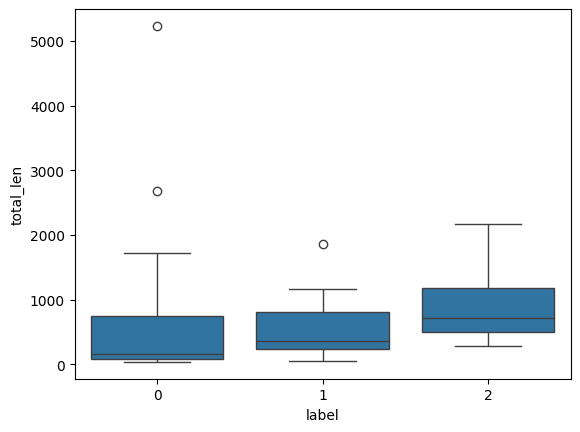

In [889]:
sns.boxplot(data=df, x='label', y='total_len')

## Observation & Conclusion: 
* Length helps distinguish very low-effort posts, but fails to cleanly separate average posts.
* Length is a noisy proxy, not a semantic signal.

#### Making one more column as **Body to title ratio** because it will tell that a post has provided how much context for a title. And also making columns for num_para, num_questions, num_exclamations to get more things about a post

In [890]:
df["body_to_title_ratio"] = df["body_len"] / (df["title_len"]+1)

In [ ]:
df['num_para'] = df["body"].str.count("\n") + 1
df['num_questions'] = df["text"].str.count("\?")
df['num_exclamations'] = df['text'].str.count("!")

df[["num_para", "num_questions", "num_exclamations"]].describe()

df["has_multiple_paras"] = (df['num_para'] > 1).astype(int)
df["has_questions"] = (df['num_questions'] > 0).astype(int)
df["has_exclamations"] = (df['num_exclamations'] > 0).astype(int)



In [892]:
df['questions_per_100_words'] = df['num_questions'] / (len(df['text'].str.split().str.len())/100)

In [893]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       63 non-null     int64  
 1   title                    63 non-null     object 
 2   body                     63 non-null     object 
 3   code                     63 non-null     object 
 4   domain                   63 non-null     object 
 5   label                    63 non-null     int64  
 6   source                   63 non-null     object 
 7   text                     63 non-null     object 
 8   title_len                63 non-null     int64  
 9   body_len                 63 non-null     int64  
 10  total_len                63 non-null     int64  
 11  body_to_title_ratio      63 non-null     float64
 12  num_para                 63 non-null     int64  
 13  num_questions            63 non-null     int64  
 14  num_exclamations         63 

In [894]:
## Dropping total length since it is highly correlated to body length
df = df.drop('total_len', axis=1)

In [895]:
df['log_num_para'] = np.log1p(df['num_para'])
df = df.drop('num_para',axis=1)

#### Let's also capture average word length in text, if low quality post will be there, there words will be short. And also capture word count for each post.

In [896]:
df["word_count"] = df['text'].str.split().str.len()
df['avg_word_len'] = df['text'].str.split().apply(
    lambda x: np.mean([len(w) for w in x]) if len(x) else 0
)

#### We can also include how many unique words are there, and also include whether the code is present or not

In [897]:
df['unique_word_ratio'] = df['text'].str.lower().str.split().apply(lambda x: len(set(x))) / df['word_count']
df['has_code'] = (df['code'].str.len() > 0).astype(int)

In [898]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       63 non-null     int64  
 1   title                    63 non-null     object 
 2   body                     63 non-null     object 
 3   code                     63 non-null     object 
 4   domain                   63 non-null     object 
 5   label                    63 non-null     int64  
 6   source                   63 non-null     object 
 7   text                     63 non-null     object 
 8   title_len                63 non-null     int64  
 9   body_len                 63 non-null     int64  
 10  body_to_title_ratio      63 non-null     float64
 11  num_questions            63 non-null     int64  
 12  num_exclamations         63 non-null     int64  
 13  has_multiple_paras       63 non-null     int64  
 14  has_questions            63 

#### Do labels differ in distribution?

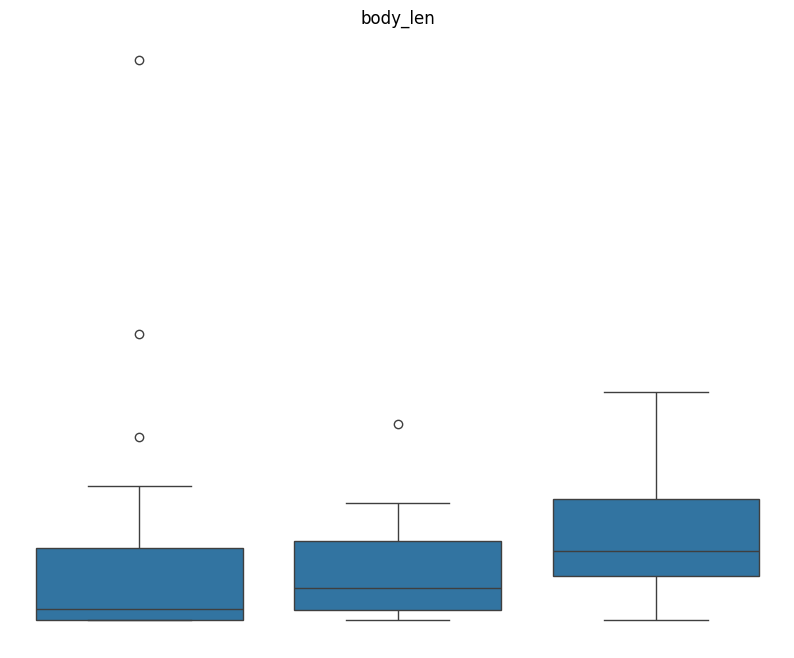

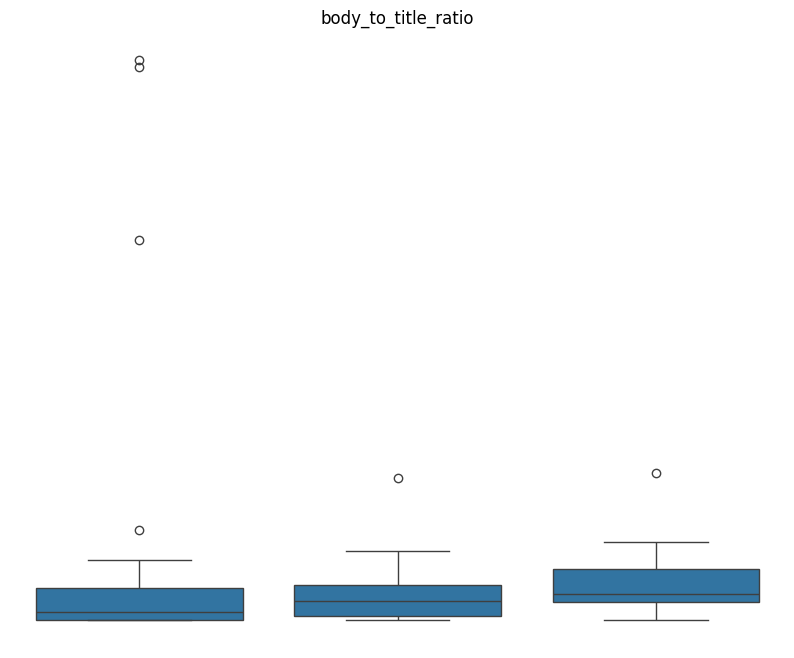

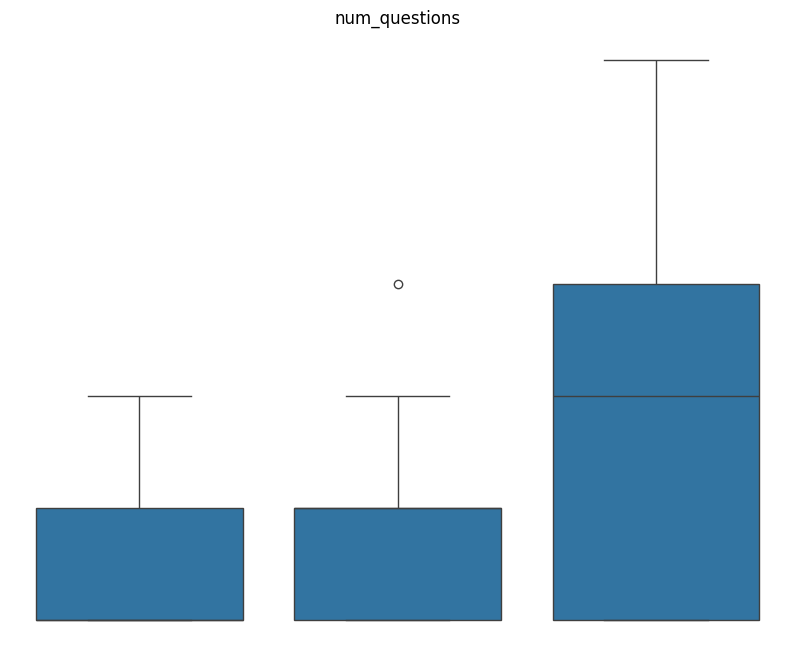

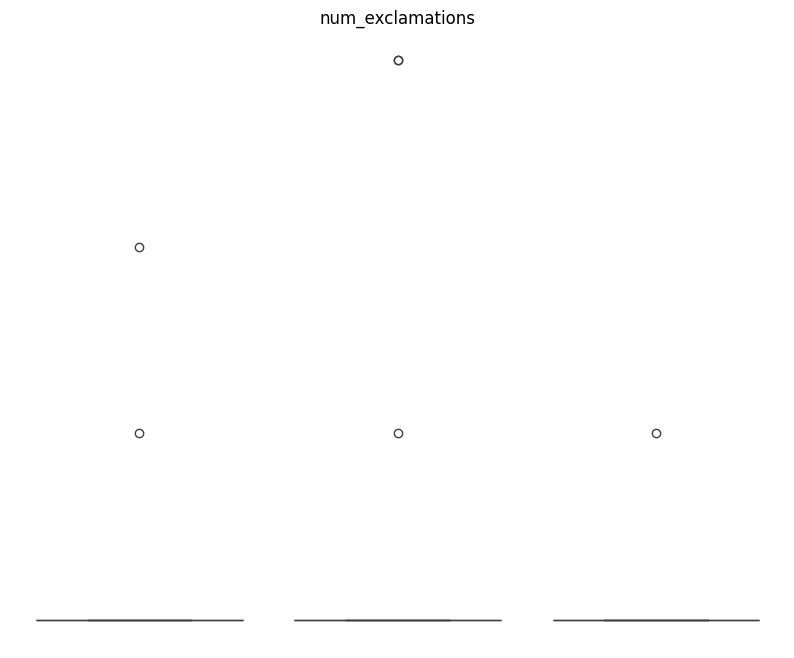

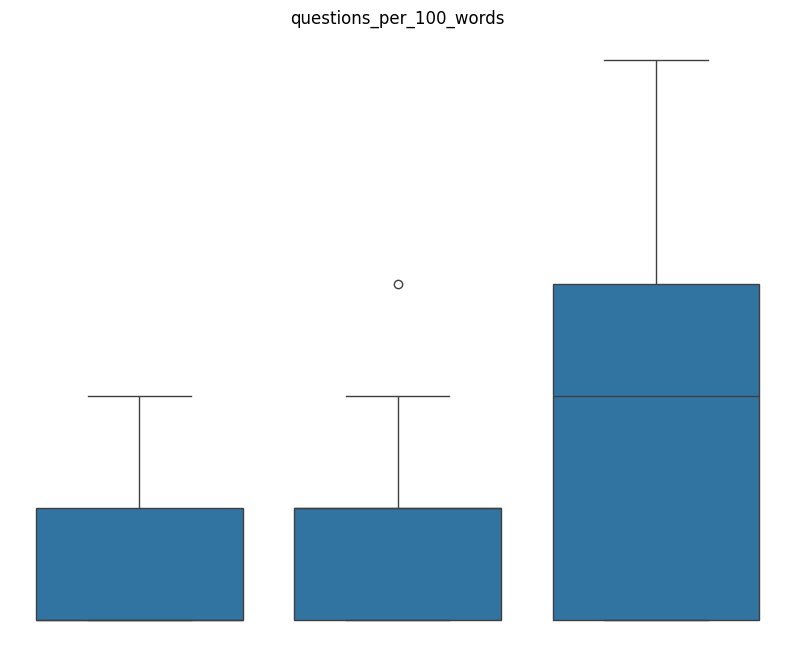

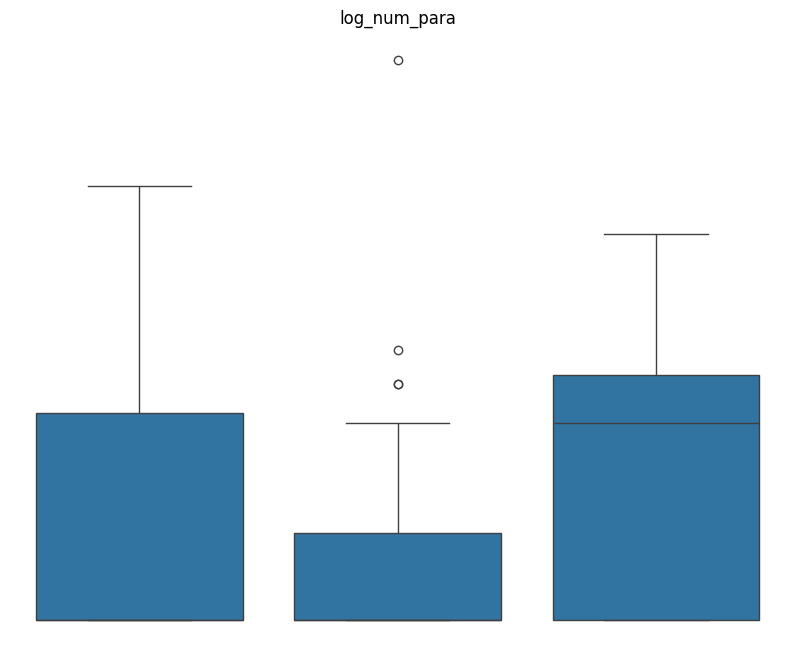

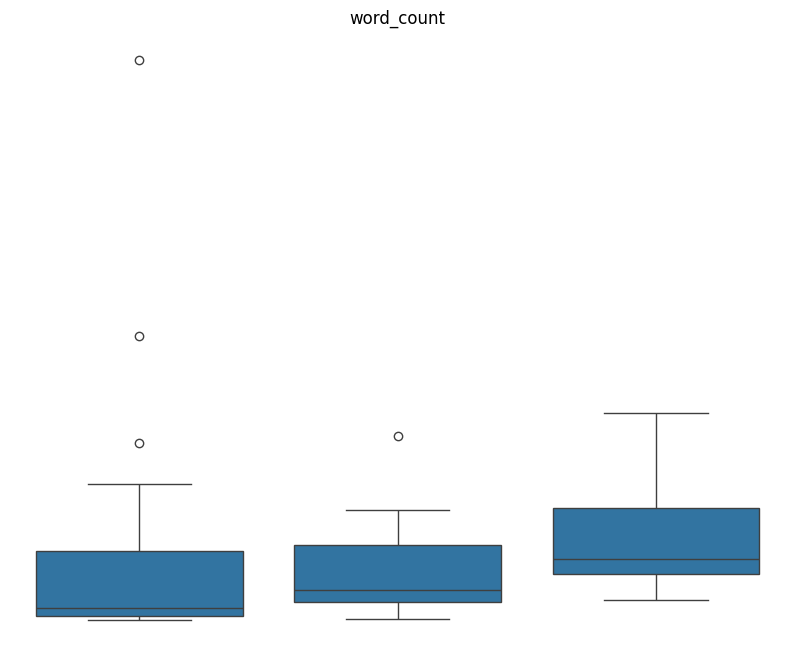

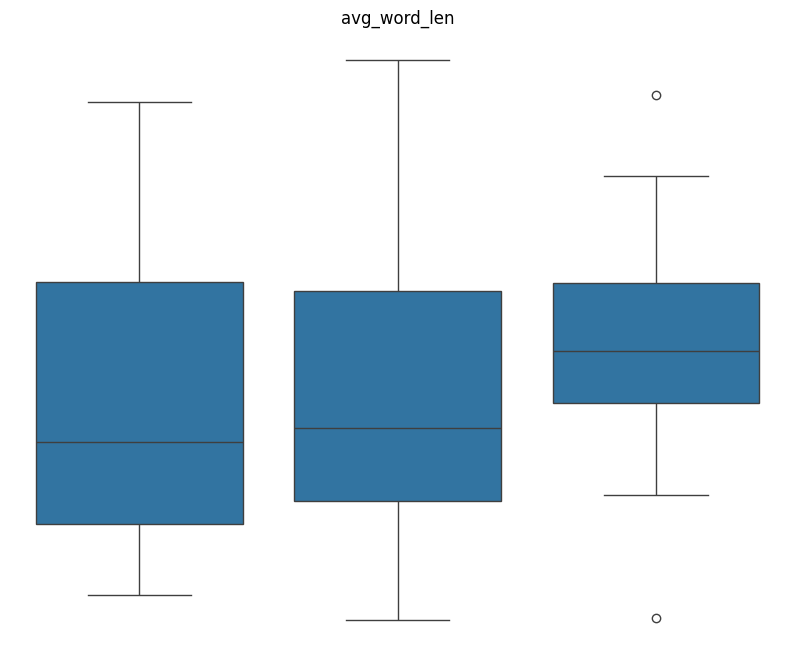

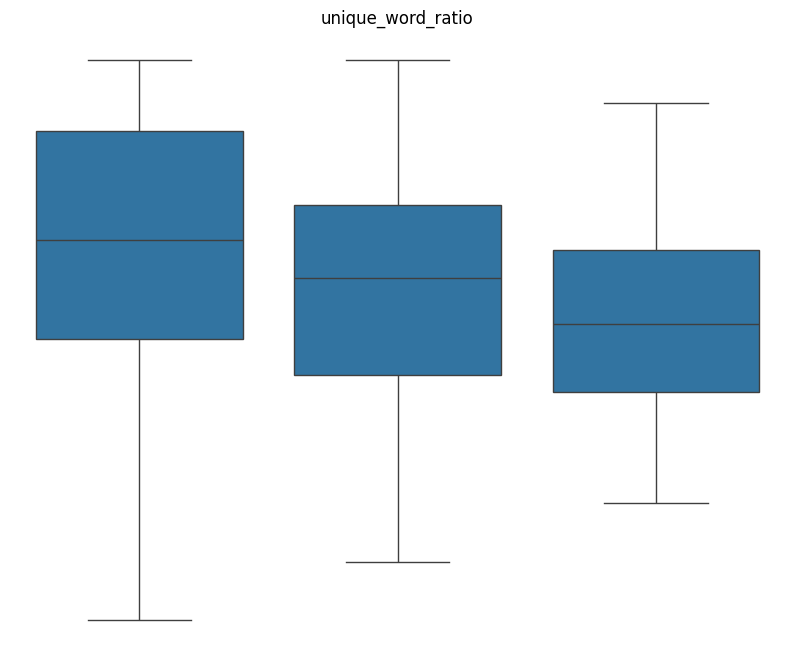

In [899]:
label_distribution_col = ['body_len',"body_to_title_ratio","num_questions","num_exclamations","questions_per_100_words","log_num_para","word_count","avg_word_len","unique_word_ratio"]
for col in label_distribution_col:
    plt.figure(figsize=(10,8))
    plt.title(f"{col}")
    sns.boxplot(x='label',y=col, data = df)
    plt.axis(False)
    plt.show()


#### Observation: 
* Unique words are more in label 0 as compared to label 1 or 2.
* Average word length of label 2 is greateer than other two labels.
* Word count is almost overlapping with somewhat greater in label 2.
* Paragraph count are more in label 0 and 2, it may have some reason, because of rants(majorily label 0) and debatable/discussion thing(label 2) are much more bigger than simple vague questions with little context and explanation(label 1).
* Question per 100 word is much higher in label 2.(Quite confusing, I though it must be label 1 which must dominate.).
* Body length is bigger in label 2(minor). And label 1 and 0 are overlapping.
* Body to title ratio is almost overlapping

## Let's try training baseline model to get whether I created the strong features or not?

In [900]:
## dropping id , domain, source
df.drop(['id','domain','source'],inplace=True, axis=1)

In [901]:
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    63 non-null     object 
 1   body                     63 non-null     object 
 2   code                     63 non-null     object 
 3   label                    63 non-null     int64  
 4   text                     63 non-null     object 
 5   title_len                63 non-null     int64  
 6   body_len                 63 non-null     int64  
 7   body_to_title_ratio      63 non-null     float64
 8   num_questions            63 non-null     int64  
 9   num_exclamations         63 non-null     int64  
 10  has_multiple_paras       63 non-null     int64  
 11  has_questions            63 non-null     int64  
 12  has_exclamations         63 non-null     int64  
 13  questions_per_100_words  63 non-null     float64
 14  log_num_para             63 

In [902]:
numerical_col = [col for col in df.columns if df[col].dtype != 'O']
numerical_col

numerical_data = df[[col for col in df.columns if df[col].dtype != 'O']]
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    63 non-null     int64  
 1   title_len                63 non-null     int64  
 2   body_len                 63 non-null     int64  
 3   body_to_title_ratio      63 non-null     float64
 4   num_questions            63 non-null     int64  
 5   num_exclamations         63 non-null     int64  
 6   has_multiple_paras       63 non-null     int64  
 7   has_questions            63 non-null     int64  
 8   has_exclamations         63 non-null     int64  
 9   questions_per_100_words  63 non-null     float64
 10  log_num_para             63 non-null     float64
 11  word_count               63 non-null     int64  
 12  avg_word_len             63 non-null     float64
 13  unique_word_ratio        63 non-null     float64
 14  has_code                 63 

In [903]:
X = numerical_data.drop('label',axis=1)
y = numerical_data['label']

In [904]:
## Doing train test split
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

numerical_col = [col for col in df.columns if df[col].dtype != 'O']
numerical_col

numerical_data = df[[col for col in df.columns if df[col].dtype != 'O']]

X = numerical_data.drop('label',axis=1)
y = numerical_data['label']



X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [905]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50, 14), (50,), (13, 14), (13,))

In [906]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [907]:
## Evaluation
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       0.40      0.67      0.50         3
           2       0.33      0.50      0.40         2

    accuracy                           0.54        13
   macro avg       0.51      0.56      0.51        13
weighted avg       0.64      0.54      0.56        13



#### Observation:

* For **Label 0**: 33% of the time only when model predicted label 0, it was actually label 0. And only 33% of total label 0 model actually classified correctly. 
* For **Label 1**: 29% of the time only when model predicted label 1, it was actually label 1. And 50% of total label 1 model actually classified correctly.
* For **Label 2**: 67% of the time when model predicted label 2, it was actually label 2. And 33% of total label 2 was actually predicted correctly.

<Axes: >

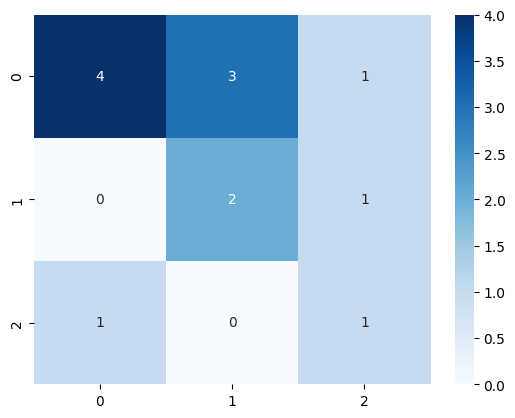

In [908]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Observation: It is getting confused with label 1. 

In [909]:
print(cm)

[[4 3 1]
 [0 2 1]
 [1 0 1]]


## TF-IDF Implementation. Just only for 'text'

In [910]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        stop_words='english'
    )),
    ('clf',LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [911]:
## Evaluation
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,pipe.predict(X_test)))


              precision    recall  f1-score   support

           0       0.60      0.38      0.46         8
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2

    accuracy                           0.23        13
   macro avg       0.20      0.12      0.15        13
weighted avg       0.37      0.23      0.28        13



<Axes: >

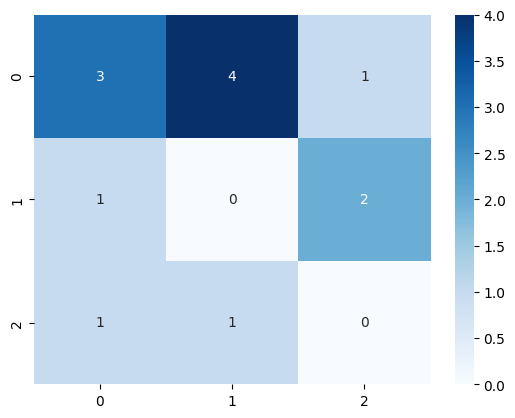

In [912]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Observation: 
TF-IDF alone is insufficient, but potentially complementary.

### Combining both TF-IDF and numeric features

In [913]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

text_feature = 'text'
numerical_feature = [col for col in df.columns if df[col].dtype != 'O' and col != 'label']
X = df[[col for col in df.columns if col == 'text' or (df[col].dtype != 'O' and col != 'label')]]
y = df['label']

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            max_features=3000,
            ngram_range=(1,2),
            min_df=2,
            stop_words='english'

        ),text_feature),
        ('num',StandardScaler(),numerical_feature)
    ]
)

pipe = Pipeline([
    ('prep',preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [914]:
## Evaluation
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       0.33      0.67      0.44         3
           2       0.50      0.50      0.50         2

    accuracy                           0.54        13
   macro avg       0.54      0.56      0.52        13
weighted avg       0.65      0.54      0.56        13



<Axes: >

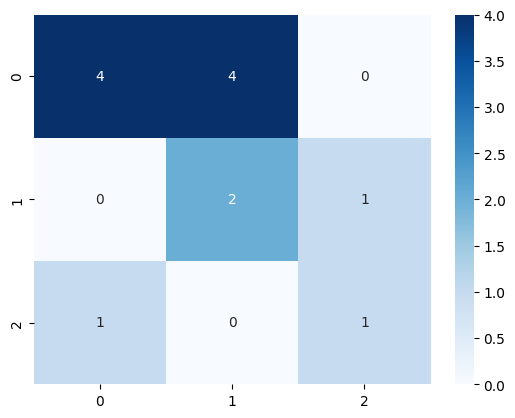

In [915]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

### Analyzing coefficient to get more details of our models decision making

In [916]:
clf = pipe.named_steps['clf']
preprocessor = pipe.named_steps['prep']
clf,preprocessor

(LogisticRegression(class_weight='balanced', max_iter=1000),
 ColumnTransformer(transformers=[('text',
                                  TfidfVectorizer(max_features=3000, min_df=2,
                                                  ngram_range=(1, 2),
                                                  stop_words='english'),
                                  'text'),
                                 ('num', StandardScaler(),
                                  ['title_len', 'body_len',
                                   'body_to_title_ratio', 'num_questions',
                                   'num_exclamations', 'has_multiple_paras',
                                   'has_questions', 'has_exclamations',
                                   'questions_per_100_words', 'log_num_para',
                                   'word_count', 'avg_word_len',
                                   'unique_word_ratio', 'has_code'])]))

In [917]:
clf.coef_.shape

(3, 403)

In [918]:
tfidf = preprocessor.named_transformers_['text']
tfidf_features =  tfidf.get_feature_names_out()
all_features = list(tfidf_features) + list(numerical_feature)
all_features

['18',
 '20',
 '30m',
 '30m wants',
 'absolute',
 'absolutely',
 'accept',
 'action',
 'actually',
 'actually works',
 'add',
 'advice',
 'afraid',
 'age',
 'amazing',
 'anymore',
 'app',
 'aren',
 'assume',
 'auth',
 'average',
 'away',
 'bad',
 'barely',
 'beginner',
 'believe',
 'best',
 'better',
 'big',
 'birth',
 'bit',
 'body',
 'bots',
 'boyfriend',
 'brain',
 'broke',
 'building',
 'builds',
 'built',
 'called',
 'calling',
 'care',
 'catch',
 'causing',
 'certainly',
 'change',
 'changed',
 'changes',
 'chasing',
 'chemistry',
 'city',
 'clarity',
 'close',
 'cmv',
 'code',
 'college',
 'come',
 'comes',
 'comfortable',
 'common',
 'company',
 'complete',
 'condition',
 'conditions',
 'constantly',
 'control',
 'conversation',
 'cookies',
 'cool',
 'countries',
 'country',
 'couples',
 'couples navigate',
 'course',
 'create',
 'curious',
 'currently',
 'dad',
 'day',
 'days',
 'death',
 'depression',
 'destruction',
 'dev',
 'development',
 'did',
 'didn',
 'difference',
 'd

In [919]:
coef_df = pd.DataFrame(
    clf.coef_,
    columns=all_features,
    index=clf.classes_
)
coef_df

,18,20,30m,30m wants,absolute,absolutely,accept,action,actually,actually works,...,num_exclamations,has_multiple_paras,has_questions,has_exclamations,questions_per_100_words,log_num_para,word_count,avg_word_len,unique_word_ratio,has_code
0,-0.036308,-0.038476,-0.044274,-0.044274,0.024163,-0.032703,-0.005137,-0.025255,-0.005844,-0.097714,...,0.099051,-0.611914,-0.406231,-0.392290,-0.159728,0.561716,-0.060962,-0.061993,0.594772,0.227636
1,0.018631,0.103290,0.048558,0.048558,0.134805,-0.009535,-0.043789,-0.032643,-0.042158,-0.088003,...,0.374227,-0.098031,0.652269,0.265684,-0.252414,-0.158511,-0.086788,-0.227301,-0.363966,-0.578524
2,0.017677,-0.064814,-0.004284,-0.004284,-0.158968,0.042238,0.048925,0.057898,0.048002,0.185717,...,-0.473278,0.709945,-0.246038,0.126606,0.412142,-0.403205,0.147750,0.289293,-0.230806,0.350888


In [920]:
## Getting top words per label 
def top_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = False).head(n)
    )

def bottom_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = True).head(n)
    )

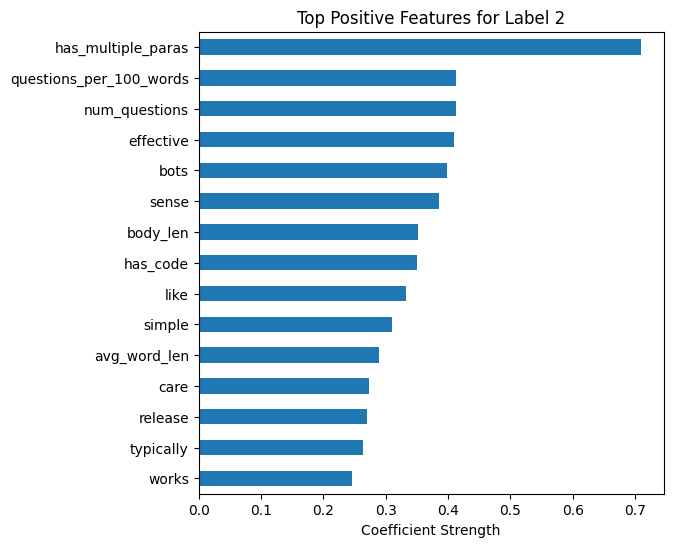

In [921]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

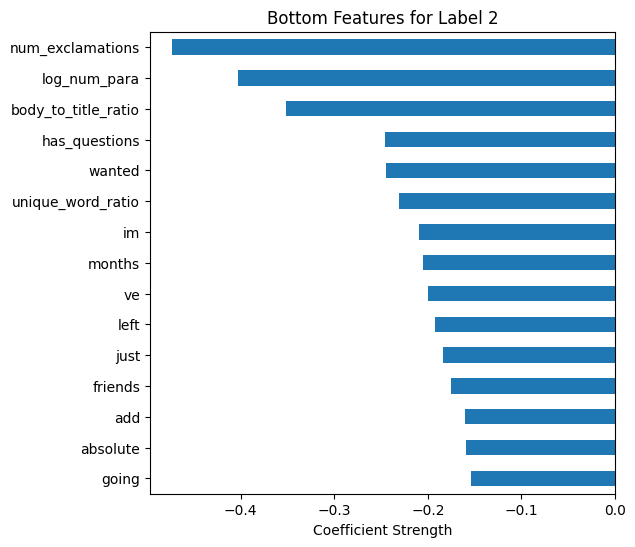

In [922]:
bottom_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
bottom_feats[::-1].plot(kind='barh')
plt.title("Bottom Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

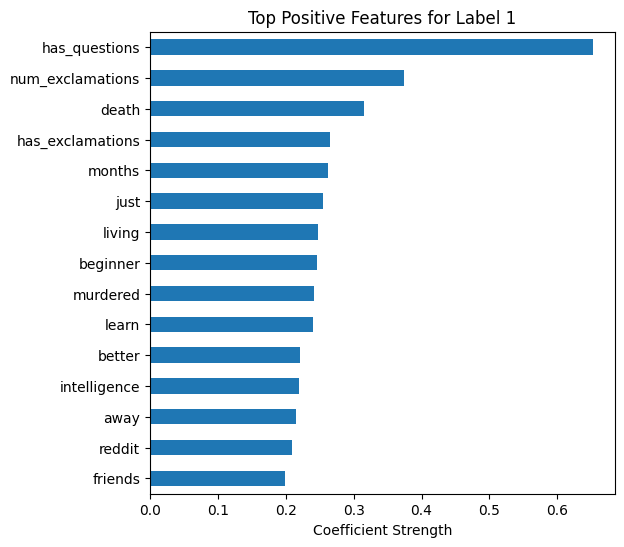

In [923]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

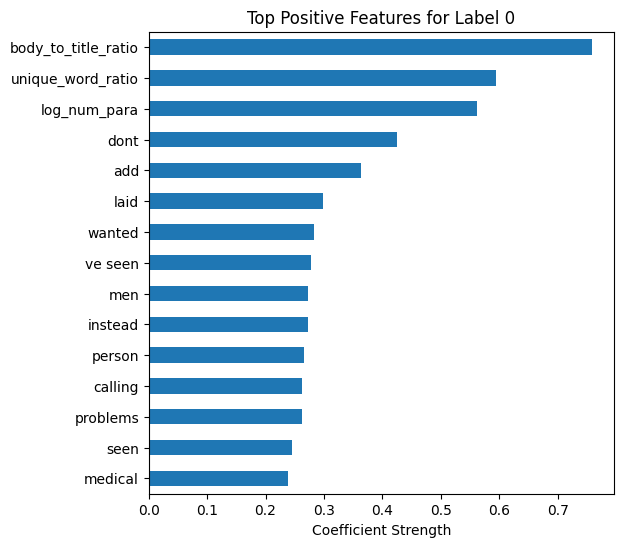

In [924]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

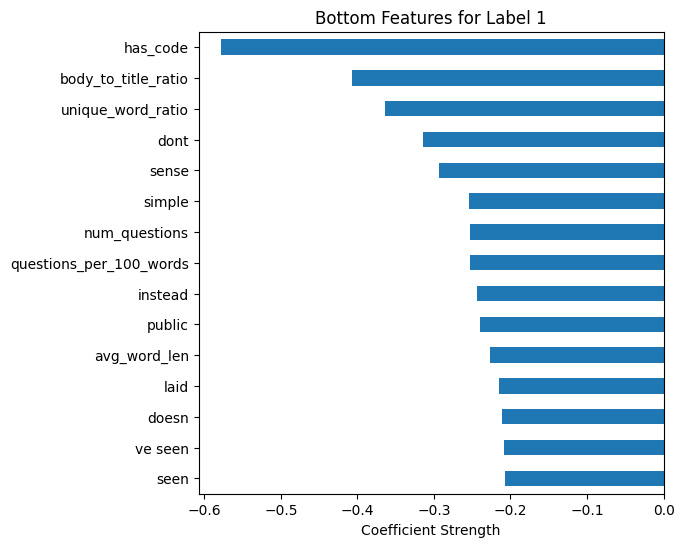

In [925]:
bottom_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
bottom_feats[::-1].plot(kind='barh')
plt.title("Bottom Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

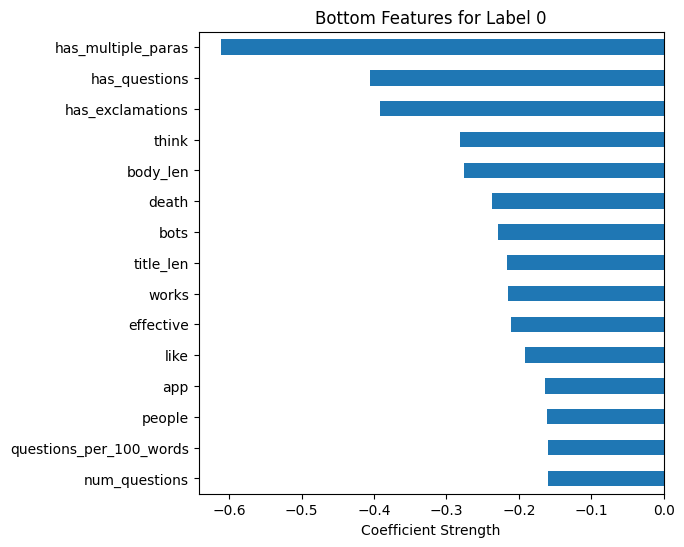

In [926]:
bottom_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
bottom_feats[::-1].plot(kind='barh')
plt.title("Bottom Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

## Observation : `body_to_title_ratio` is confusing between label 0 and label 2. Many label 2 posts could be classified as label 0. so changing it to `log_btt`, `log_btt_x_has_questions`, it will check btt_ratio must have question, it should not be all rants

In [927]:
df = df.drop(columns=['body_to_title_ratio'])

In [928]:
numerical_feature = [col for col in df.columns if df[col].dtype != 'O' and col != 'label']
numerical_feature

['title_len',
 'body_len',
 'num_questions',
 'num_exclamations',
 'has_multiple_paras',
 'has_questions',
 'has_exclamations',
 'questions_per_100_words',
 'log_num_para',
 'word_count',
 'avg_word_len',
 'unique_word_ratio',
 'has_code']

#### Let's make `body_to_title_ratio` pass through log, to prevent it from exploding

In [929]:
df['log_btt'] = (
    np.log1p(df['body_len']) - np.log1p(df['title_len'])
)

#### Adding `log_btt_x_has_questions` it answers a questions "Is the post long and question driven? not just the rant "

In [930]:
df['log_btt_x_has_questions'] = (
    df['log_btt'] * df['has_questions']
)


In [931]:
numerical_feature = [
    col for col in df.columns
    if df[col].dtype != 'O' and col != 'label'
]
numerical_feature

['title_len',
 'body_len',
 'num_questions',
 'num_exclamations',
 'has_multiple_paras',
 'has_questions',
 'has_exclamations',
 'questions_per_100_words',
 'log_num_para',
 'word_count',
 'avg_word_len',
 'unique_word_ratio',
 'has_code',
 'log_btt',
 'log_btt_x_has_questions']

### Checking for both new feature

In [932]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=3000,
             ngram_range=(1,2),
             min_df=2,
             stop_words='english'
         ),
         'text'
        ),
        ('num', StandardScaler(), numerical_feature)
    ]
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

X = df[['text'] + numerical_feature]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [933]:
print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.33      0.67      0.44         3
           2       0.40      1.00      0.57         2

    accuracy                           0.46        13
   macro avg       0.58      0.64      0.47        13
weighted avg       0.75      0.46      0.44        13



<Axes: >

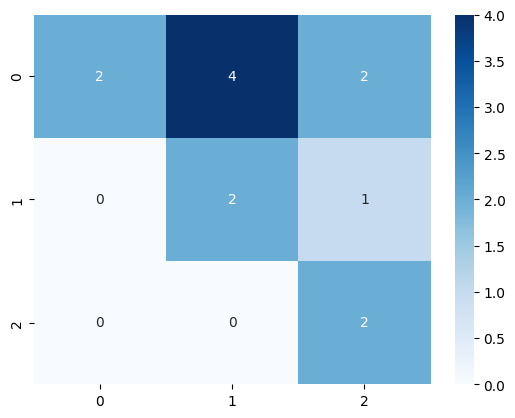

In [934]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [935]:
clf = pipe.named_steps['clf']
preprocessor = pipe.named_steps['prep']

tfidf = preprocessor.named_transformers_['text']
tfidf_features = tfidf.get_feature_names_out()

all_features = list(tfidf_features) + numerical_feature

coef_df = pd.DataFrame(
    clf.coef_,
    columns=all_features,
    index=clf.classes_
)


In [936]:
## Getting top words per label 
def top_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = False).head(n)
    )

def bottom_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = True).head(n)
    )

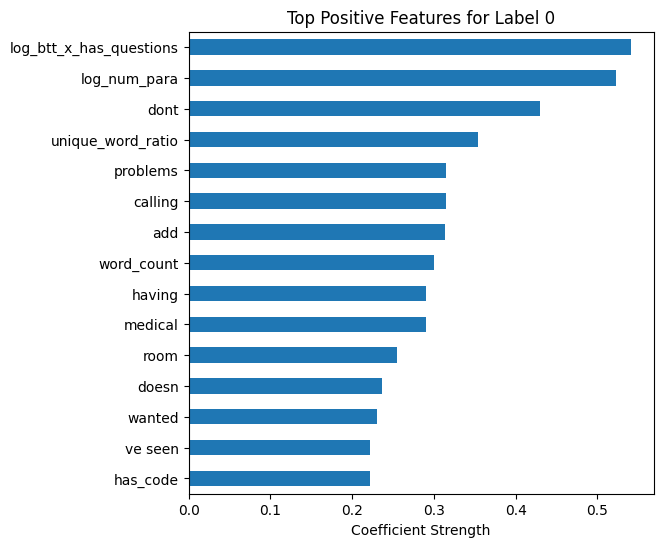

In [937]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

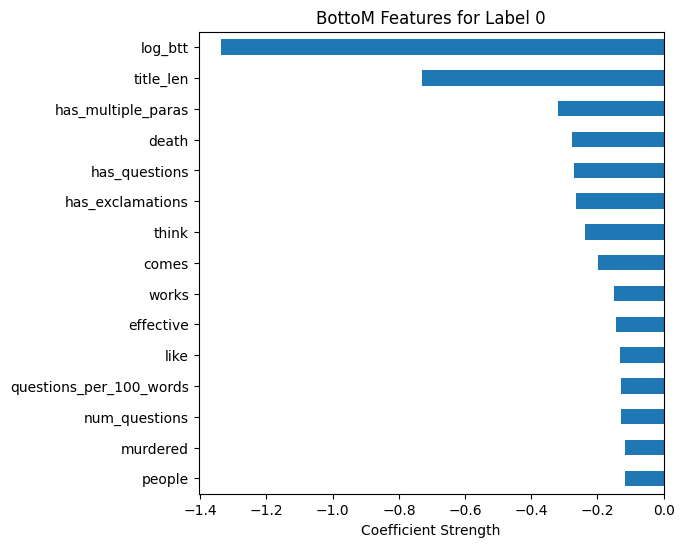

In [938]:
botton_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

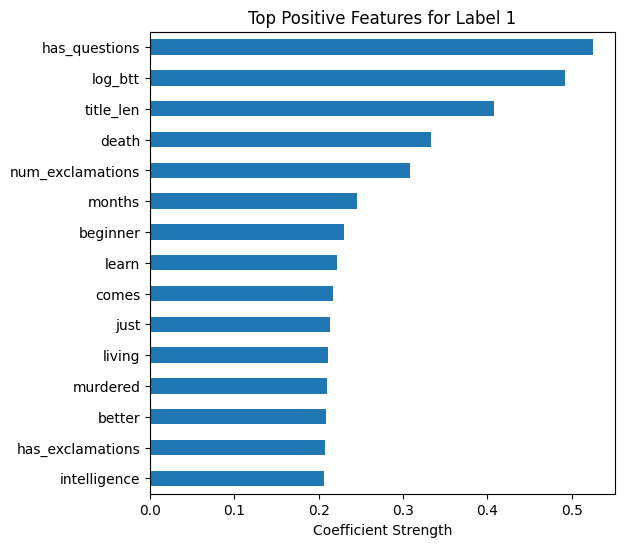

In [939]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

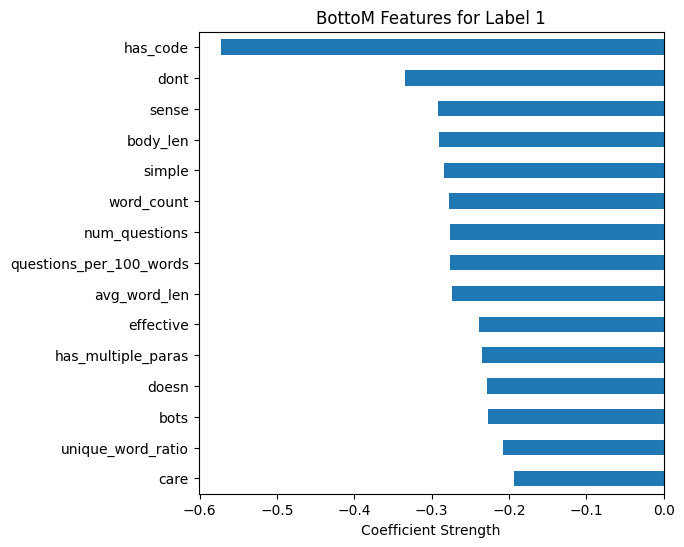

In [940]:
botton_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

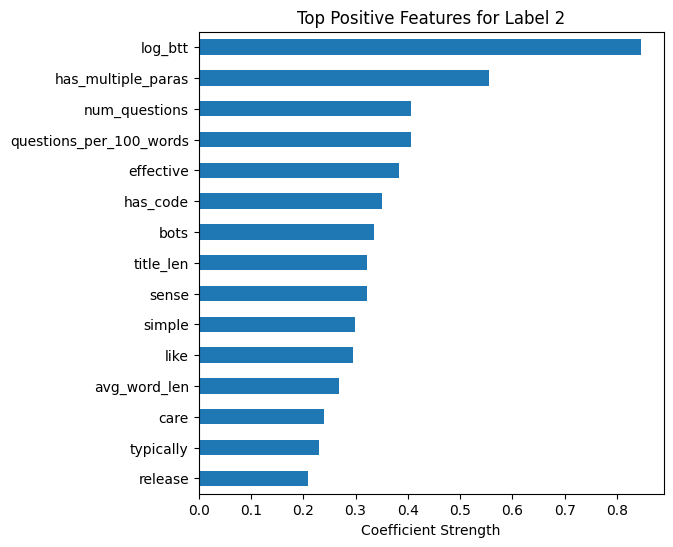

In [941]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

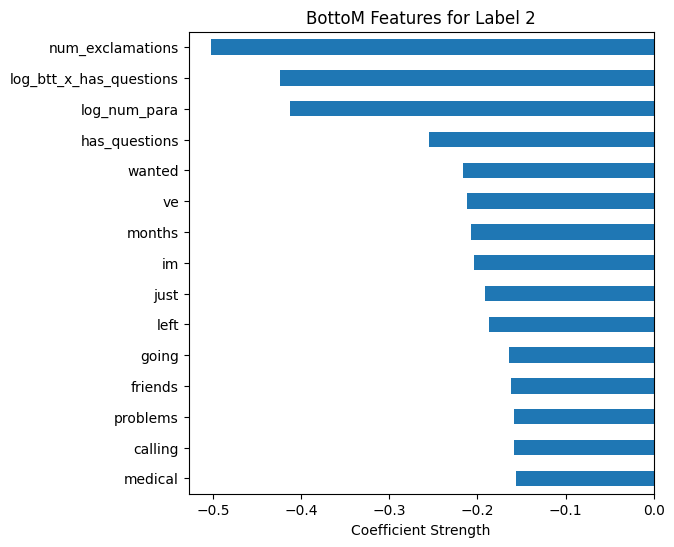

In [942]:
botton_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

<Axes: xlabel='label', ylabel='log_btt_x_has_questions'>

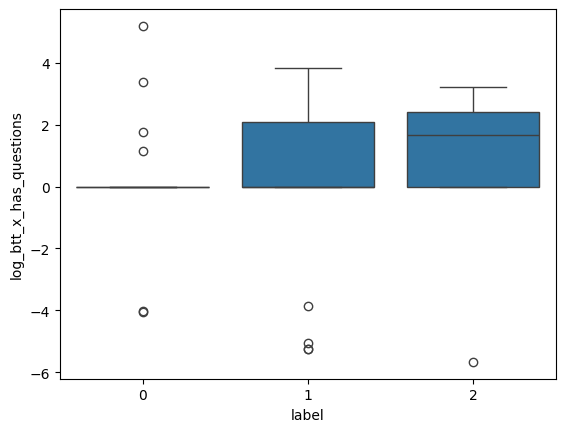

In [943]:
sns.boxplot(x='label', y='log_btt_x_has_questions', data=df)


### Observation:  I think model is confusing on label 0 and label 2 that which question + big para is label 0 (because sometimes rants also has questions) or label 2(a good discussion question)

#### Let's add one more feature, that tries to find rhetorical and discussion questions. That means that model should have question, but that question must not be rhetoric, then label it 2.

#### A very simple difference between rhetoric question and discussion questions is:
* Rhetoric questions are dense, one after another
* Discussion questions are more sparse, but contextual

Our feature will be `question_density_per_para` in a good discussion/debatable post each para will have less questions, and more context. But opposite for rants, that has questions like "Why me....?"Why do I always have to be...."

In [944]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    63 non-null     object 
 1   body                     63 non-null     object 
 2   code                     63 non-null     object 
 3   label                    63 non-null     int64  
 4   text                     63 non-null     object 
 5   title_len                63 non-null     int64  
 6   body_len                 63 non-null     int64  
 7   num_questions            63 non-null     int64  
 8   num_exclamations         63 non-null     int64  
 9   has_multiple_paras       63 non-null     int64  
 10  has_questions            63 non-null     int64  
 11  has_exclamations         63 non-null     int64  
 12  questions_per_100_words  63 non-null     float64
 13  log_num_para             63 non-null     float64
 14  word_count               63 

In [945]:
df['question_density_per_para'] = (df['num_questions'] / (df['body'].str.count('\n') + 1))

<Axes: xlabel='label', ylabel='question_density_per_para'>

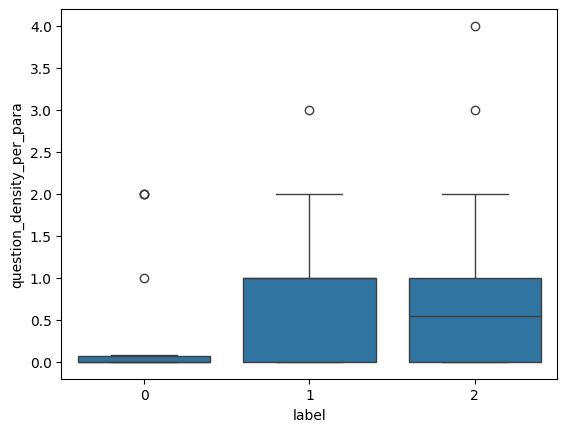

In [946]:
sns.boxplot(
    x='label',
    y='question_density_per_para',
    data=df
)

#### My assumption failed that rhetoric posts has a lot of questions. Let's remove other question related feature and keep this and try checking the model again

In [947]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      63 non-null     object 
 1   body                       63 non-null     object 
 2   code                       63 non-null     object 
 3   label                      63 non-null     int64  
 4   text                       63 non-null     object 
 5   title_len                  63 non-null     int64  
 6   body_len                   63 non-null     int64  
 7   num_questions              63 non-null     int64  
 8   num_exclamations           63 non-null     int64  
 9   has_multiple_paras         63 non-null     int64  
 10  has_questions              63 non-null     int64  
 11  has_exclamations           63 non-null     int64  
 12  questions_per_100_words    63 non-null     float64
 13  log_num_para               63 non-null     float64
 

In [948]:
df = df.drop(columns=['has_questions','num_questions'])

In [949]:
## Retrain the model
numerical_feature = [
    col for col in df.columns
    if df[col].dtype != 'O' and col != 'label'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=3000,
             ngram_range=(1,2),
             min_df=2,
             stop_words='english'
         ),
         'text'
        ),
        ('num', StandardScaler(), numerical_feature)
    ]
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

X = df[['text'] + numerical_feature]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.29      0.67      0.40         3
           2       0.50      1.00      0.67         2

    accuracy                           0.46        13
   macro avg       0.60      0.64      0.49        13
weighted avg       0.76      0.46      0.44        13



<Axes: >

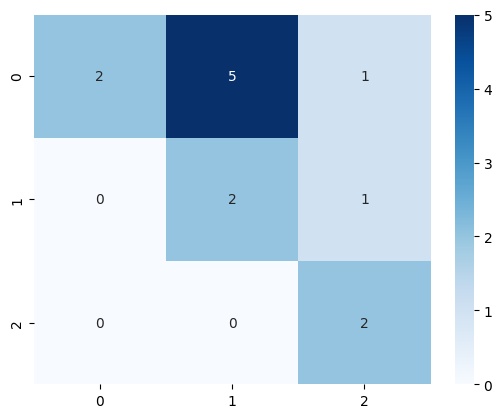

In [950]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [951]:
clf = pipe.named_steps['clf']
preprocessor = pipe.named_steps['prep']

tfidf = preprocessor.named_transformers_['text']
tfidf_features = tfidf.get_feature_names_out()

all_features = list(tfidf_features) + numerical_feature

coef_df = pd.DataFrame(
    clf.coef_,
    columns=all_features,
    index=clf.classes_
)
## Getting top words per label 
def top_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = False).head(n)
    )

def bottom_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = True).head(n)
    )

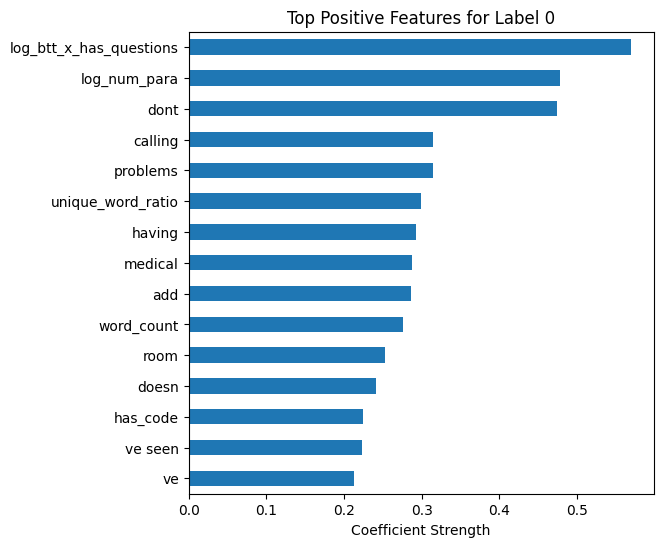

In [952]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

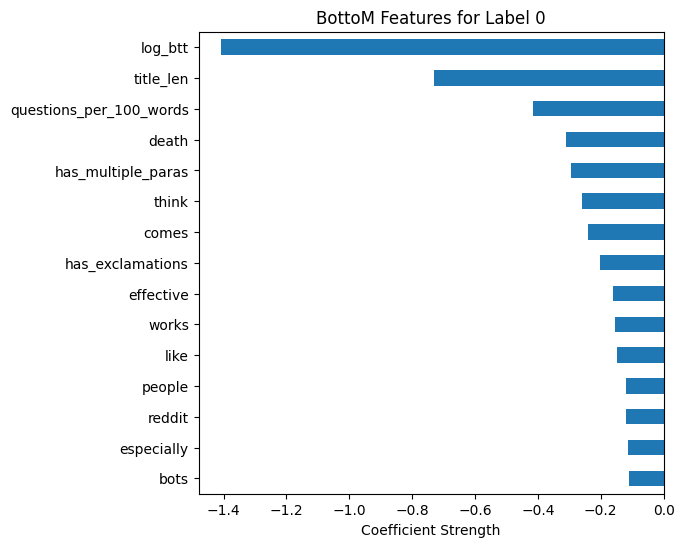

In [953]:
botton_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

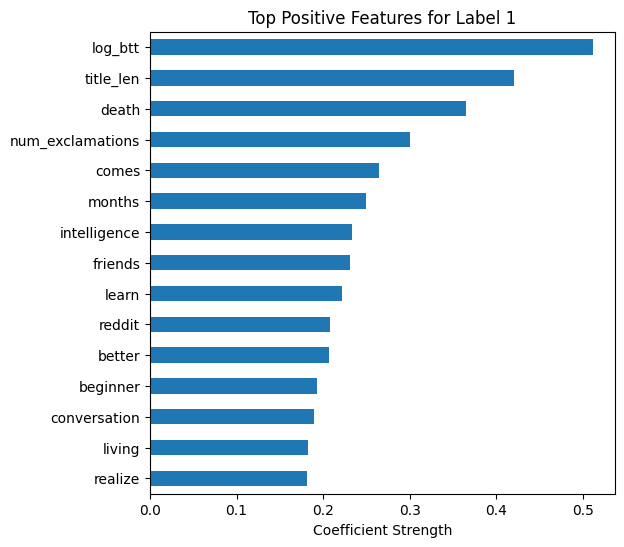

In [954]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

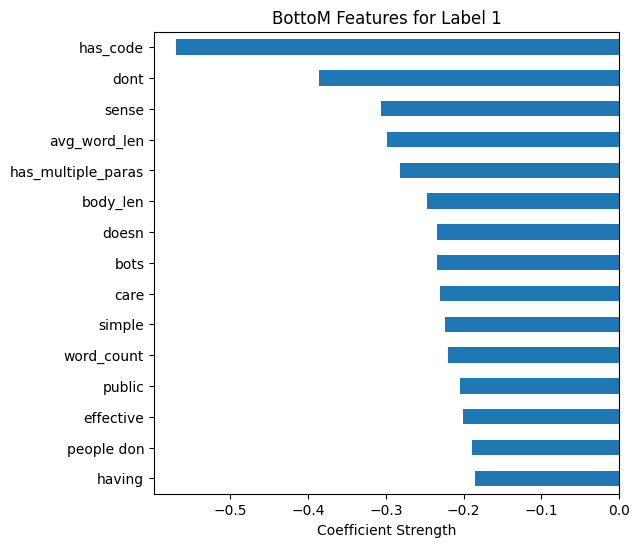

In [955]:
botton_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

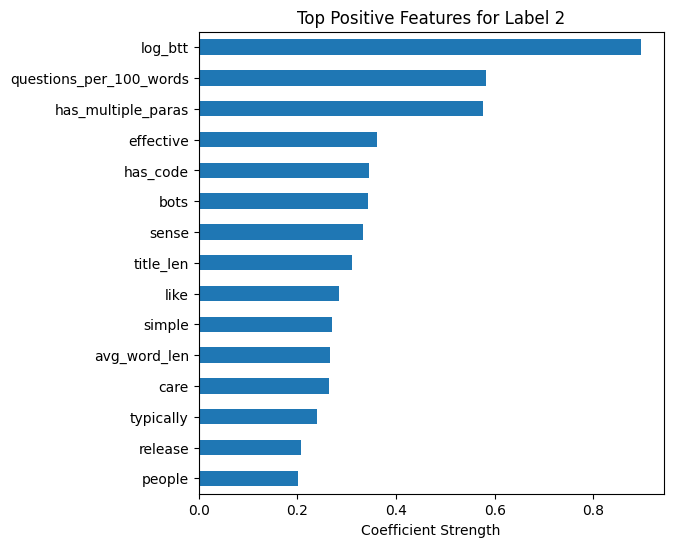

In [956]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

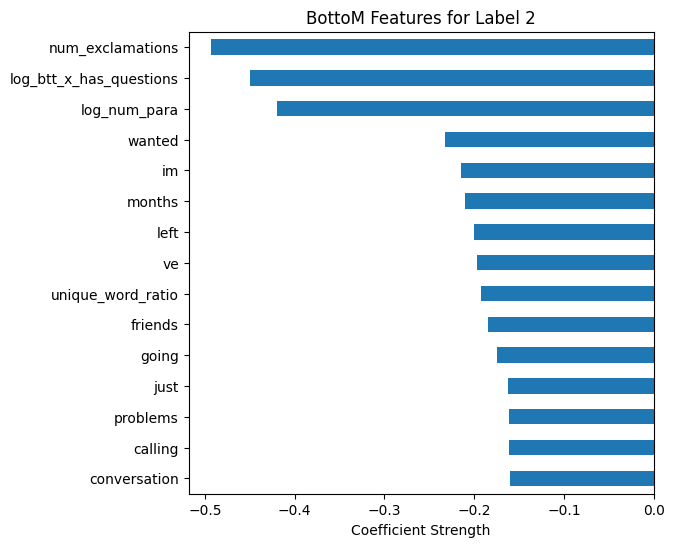

In [957]:
botton_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

### **Observation**: I think For each split and run, I checked top 5 (or more) positive & negative features per label and they make sense and point in the same direction.

#### Let's add one more feature `first_person_ratio`, it will helps find out rants vs good discussion

In [958]:
import re
FIRST_PERSON = {"i","me","my","mine","we","us","our","ours"}

def first_person_ratio(text):
    words = re.findall(r"\bw+\b",text.lower())
    if not words:
        return 0.0
    fp_count = sum(1 for w in words if w in FIRST_PERSON)
    return fp_count/ len(words)

df['first_person_ratio'] = df['text'].apply(first_person_ratio)

In [959]:
numerical_feature.append('first_person_ratio')

In [960]:
## Retrain the model
numerical_feature = [
    col for col in df.columns
    if df[col].dtype != 'O' and col != 'label'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=3000,
             ngram_range=(1,2),
             min_df=2,
             stop_words='english'
         ),
         'text'
        ),
        ('num', StandardScaler(), numerical_feature)
    ]
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

X = df[['text'] + numerical_feature]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.29      0.67      0.40         3
           2       0.50      1.00      0.67         2

    accuracy                           0.46        13
   macro avg       0.60      0.64      0.49        13
weighted avg       0.76      0.46      0.44        13



<Axes: >

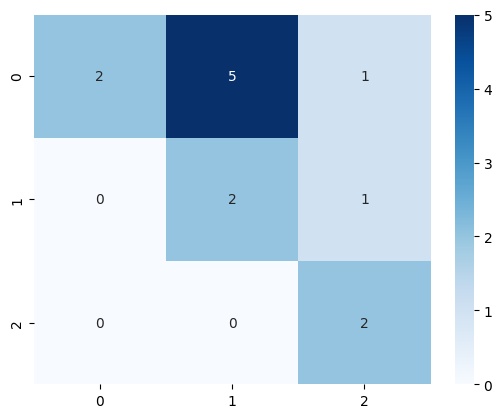

In [961]:
cm = confusion_matrix(y_test, pipe.predict(X_test))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

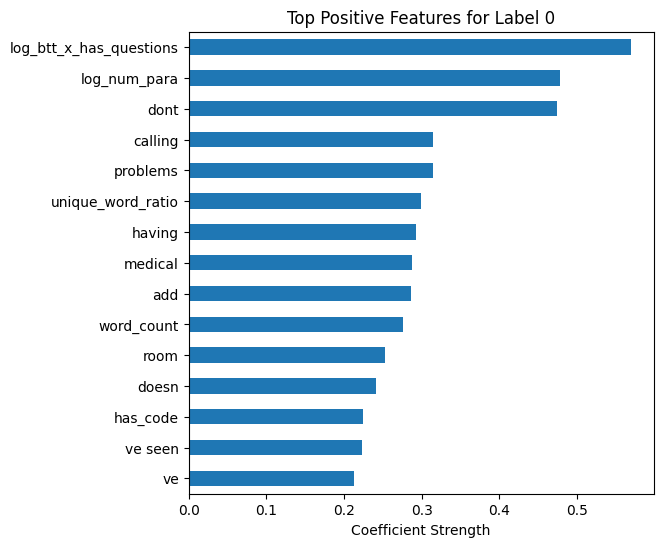

In [962]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

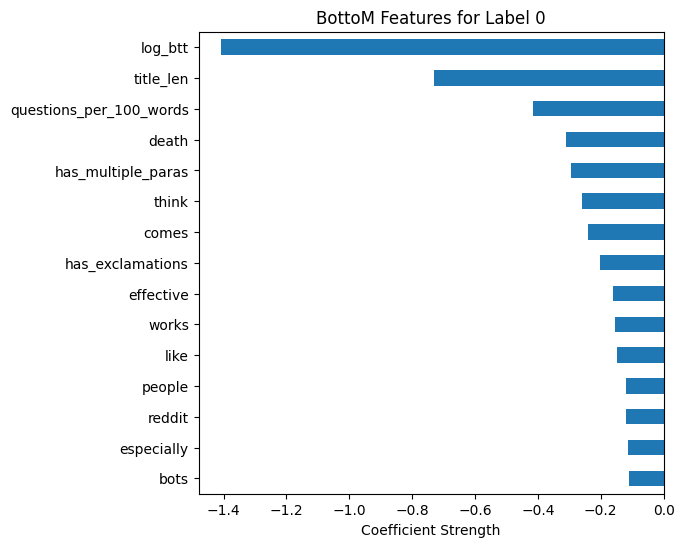

In [963]:
botton_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

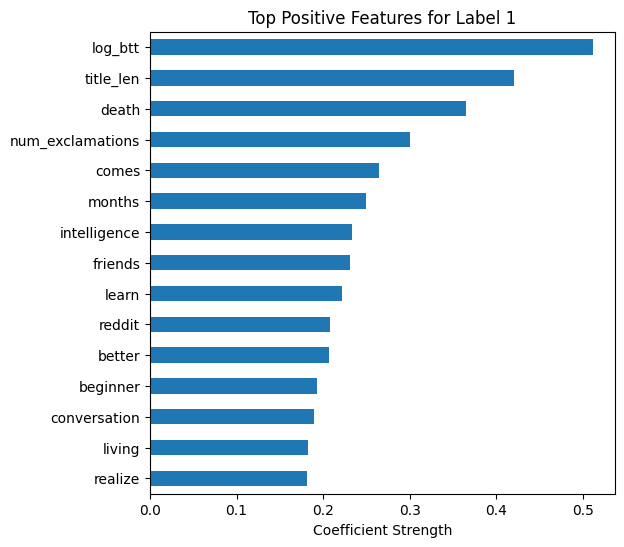

In [964]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

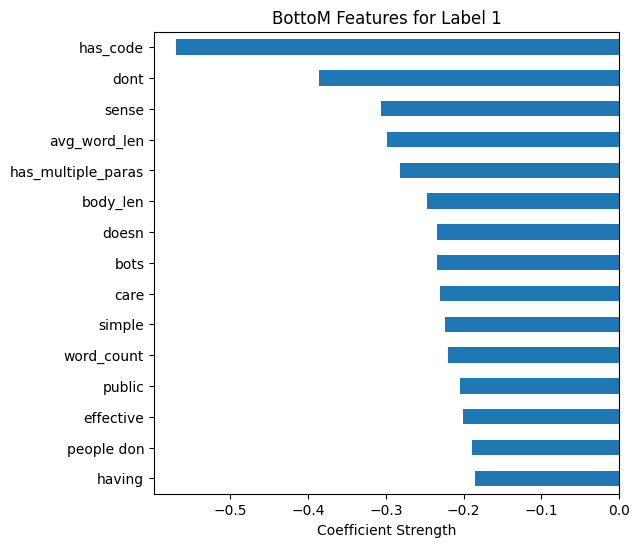

In [965]:
botton_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

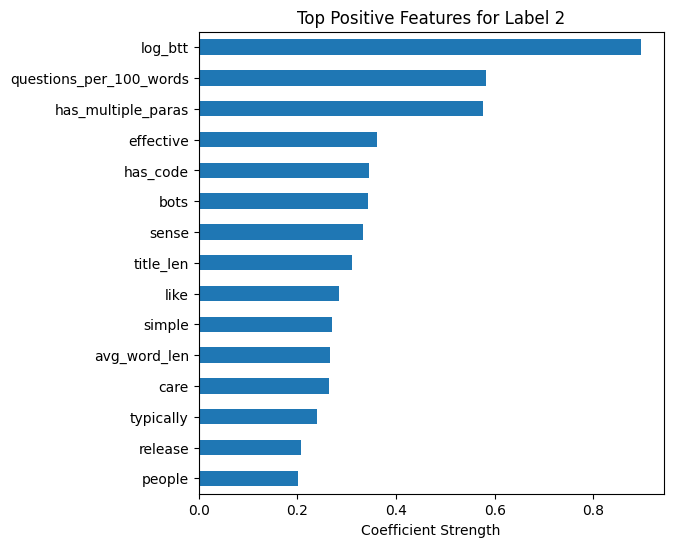

In [966]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

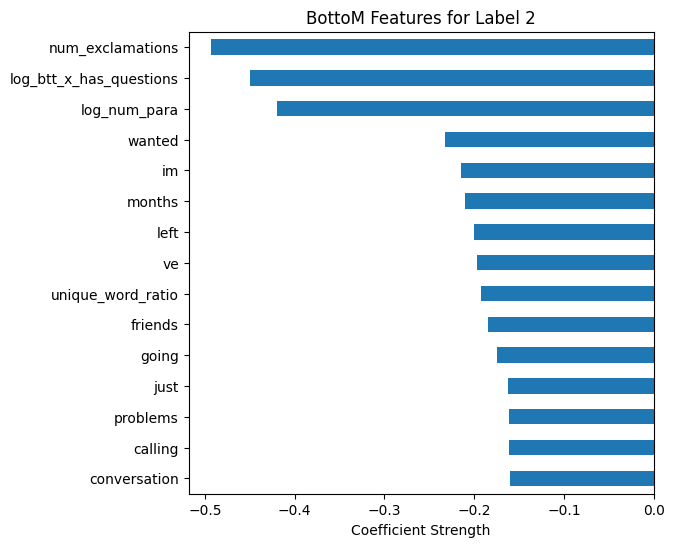

In [967]:
botton_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

In [968]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      63 non-null     object 
 1   body                       63 non-null     object 
 2   code                       63 non-null     object 
 3   label                      63 non-null     int64  
 4   text                       63 non-null     object 
 5   title_len                  63 non-null     int64  
 6   body_len                   63 non-null     int64  
 7   num_exclamations           63 non-null     int64  
 8   has_multiple_paras         63 non-null     int64  
 9   has_exclamations           63 non-null     int64  
 10  questions_per_100_words    63 non-null     float64
 11  log_num_para               63 non-null     float64
 12  word_count                 63 non-null     int64  
 13  avg_word_len               63 non-null     float64
 

#### Error taxonomy:
Let's see which type of data is actually failing.

In [969]:
y_pred = pipe.predict(X_test)

In [970]:
## Analysis data_frame

analysis_df = X_test.copy()

analysis_df['true_label'] = y_test.values
analysis_df['pred_label'] = y_pred
analysis_df['correct'] = analysis_df['true_label'] == analysis_df['pred_label']


In [971]:
wrong_df = analysis_df[analysis_df['correct'] == False]
right_df = analysis_df[analysis_df['correct'] == True]


In [972]:
wrong_df[['text', 'true_label', 'pred_label']].head(10)


,text,true_label,pred_label
61,"My biggest fear is Alzheimer’s\n\nNot for me, ...",0,1
57,PSA: When you reach out to a co-worker on slac...,0,1
43,I wanna sudoku\n\nGod I wanna sudoku. Was cont...,0,1
16,I’m dead soon\n\nHi I’m Macy and my parents ar...,0,2
12,I changed a road sign to make my commute easie...,0,1
25,Can't afford to live and I've exhausted all ot...,0,1
9,Approaches to testing a unit of code that make...,1,2


## Now let's make an `error_df` where we store all the errors with their categories and notes like why I think this error happened
### There will be **four categories** of errors:
* **A** -> Label ambiguity(human disagreement) -> Humans themselves can reasonably disagree on the label.
* **B** -> Feature label mismatch -> The model is using valid signals, but they don’t correspond to how I define labels.
* **C** -> Data sparsity/instability -> Too little data → coefficients jump around → fragile rules.
* **D** -> Representational gap (semantic or pragmatic) -> Bag-of-words + shallow features cannot capture intent or pragmatics.

In [973]:
analysis_df

,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,questions_per_100_words,log_num_para,word_count,avg_word_len,unique_word_ratio,has_code,log_btt,log_btt_x_has_questions,question_density_per_para,first_person_ratio,true_label,pred_label,correct
61,"My biggest fear is Alzheimer’s\n\nNot for me, ...",30,133,0,1,0,0.000000,1.098612,33,4.000000,0.787879,0,1.463853,0.000000,0.0,0.0,0,1,False
57,PSA: When you reach out to a co-worker on slac...,149,403,0,1,0,0.000000,1.791759,97,4.690722,0.793814,0,0.990780,0.000000,0.0,0.0,0,1,False
0,Why do some people in 2025 still believe that ...,155,0,0,0,0,1.587302,0.693147,31,4.032258,0.935484,0,-5.049856,-5.049856,1.0,0.0,1,1,True
43,I wanna sudoku\n\nGod I wanna sudoku. Was cont...,14,2658,0,0,0,0.000000,0.693147,525,4.093333,0.518095,0,5.177655,0.000000,0.0,0.0,0,1,False
5,"Why do strangers in Western countries ask ""How...",111,521,0,0,0,6.349206,0.693147,109,4.816514,0.743119,0,1.539169,1.539169,4.0,0.0,2,2,True
36,marketo form validation with fetch\n\nI added ...,34,248,0,0,0,0.000000,0.693147,50,4.680000,0.680000,1,1.962105,0.000000,0.0,0.0,2,2,True
16,I’m dead soon\n\nHi I’m Macy and my parents ar...,13,1703,0,1,0,0.000000,1.098612,330,4.206061,0.584848,0,4.801676,0.000000,0.0,0.0,0,2,False
12,I changed a road sign to make my commute easie...,61,1185,0,1,0,0.000000,1.791759,255,3.894118,0.552941,0,2.951207,0.000000,0.0,0.0,0,1,False
25,Can't afford to live and I've exhausted all ot...,57,333,0,0,0,3.174603,0.693147,74,4.297297,0.783784,0,1.750698,1.750698,2.0,0.0,0,1,False
60,What is best crime thriller series to watch on...,55,0,0,0,0,1.587302,0.693147,10,4.600000,1.000000,0,-4.025352,-4.025352,1.0,0.0,0,0,True


In [974]:
error_df = analysis_df[analysis_df['correct'] == False].copy()

error_df = error_df[[
    'text',
    'true_label',
    'pred_label'
]]

error_df['error_type'] = ""
error_df['error_subtype'] = ""
error_df['notes'] = ""


In [975]:
error_df

,text,true_label,pred_label,error_type,error_subtype,notes
61,"My biggest fear is Alzheimer’s\n\nNot for me, ...",0,1,,,
57,PSA: When you reach out to a co-worker on slac...,0,1,,,
43,I wanna sudoku\n\nGod I wanna sudoku. Was cont...,0,1,,,
16,I’m dead soon\n\nHi I’m Macy and my parents ar...,0,2,,,
12,I changed a road sign to make my commute easie...,0,1,,,
25,Can't afford to live and I've exhausted all ot...,0,1,,,
9,Approaches to testing a unit of code that make...,1,2,,,


In [976]:
error_df = error_df.reset_index(drop=True)


Errors explanations

(By mistake I ran all the cells again, please check /data/post_quality/processed/error_taxonomy_v1.csv)

1. “I got called a fascist today”

This post is a long, emotional, first-person narrative describing a social conflict. While it does not explicitly ask for advice, it clearly invites broader discussion and perspectives, which aligns with label 2. However, the model interprets strong first-person language and emotional tone as advice-seeking. This is a semantic failure, where intent (social commentary) is mistaken for help-seeking.

Error Type = D
(Semantic intent not captured by tf-idf)

2. “Vegas didn’t evolve, it got murdered by MGM and Caesars”

This post is an opinionated rant that is designed to provoke reactions and discussion. Even without explicit questions, it functions as a discussion seed, which is why label 1 is correct. The model incorrectly treats declarative, narrative posts as low-effort statements (label 0), showing a limitation of bag-of-words in detecting discourse role.

Error Type = D
(Opinionated discussion seed mistaken as statement)

3. “What’s a subtle sign of very low intelligence?”

This is an open-ended opinion question meant to gather diverse perspectives, not personal advice. By task definition, it belongs to label 1. The model learned a shortcut where clear question structure ⇒ label 2, which is statistically plausible but logically wrong here. Additionally, the model lacks a task-level rule distinguishing opinion questions from advice-seeking questions.

Error Type = B + C
(Question-pattern bias + missing domain rule)

4. “Learn programming as an absolute beginner”

This post asks for recommendations and guidance but does not challenge ideas or introduce a discussion topic. While the language resembles advice-seeking (which the model detects correctly), by task definition it belongs to label 1, not label 2. This is a borderline case where human labeling itself is debatable, and the confusion comes from task boundaries rather than model failure.

Error Type = A
(Borderline ambiguity between label 1 and label 2)

5. “Why are genetic differences in intelligence between races often rejected?”

This is a long, analytical, hypothesis-driven question that invites debate. Linguistically and semantically, it resembles a high-quality discussion (label 2), which is why the model predicts it as such. However, by dataset definition, opinion debates fall under label 1. This mismatch arises because the model cannot infer task-specific labeling rules from text alone.

Error Type = C + D
(Task rule mismatch + semantic depth beyond tf-idf)

In [977]:
### Filling the table
# Row 0
error_df.loc[0, 'error_type'] = "D"
error_df.loc[0, 'error_subtype'] = "Narrative social critique mistaken as advice-seeking"
error_df.loc[0, 'notes'] = (
    "Emotional first-person narrative invites discussion, "
    "but model learned proxy: first-person + emotion -> label 1"
)

# Row 1
error_df.loc[1, 'error_type'] = "D"
error_df.loc[1, 'error_subtype'] = "Opinionated rant functioning as discussion seed"
error_df.loc[1, 'notes'] = (
    "Declarative opinion post intended to provoke responses, "
    "but absence of explicit question pushed it to label 0"
)

# Row 2
error_df.loc[2, 'error_type'] = "B+C"
error_df.loc[2, 'error_subtype'] = "Open-ended opinion question mistaken as advice"
error_df.loc[2, 'notes'] = (
    "Model learned shortcut: clear question -> label 2, "
    "but this is opinion solicitation, not advice-seeking"
)

# Row 3
error_df.loc[3, 'error_type'] = "A"
error_df.loc[3, 'error_subtype'] = "Beginner guidance post borderline between label 1 and 2"
error_df.loc[3, 'notes'] = (
    "Advice-seeking detected correctly, but task definition places "
    "beginner recommendations under label 1, making this borderline"
)

# Row 4
error_df.loc[4, 'error_type'] = "C+D"
error_df.loc[4, 'error_subtype'] = "Analytical debate question mistaken as high-quality discussion"
error_df.loc[4, 'notes'] = (
    "Semantic depth and hypothesis framing pushed prediction to label 2, "
    "but task definition treats this as opinion debate (label 1)"
)


In [978]:
error_df

,text,true_label,pred_label,error_type,error_subtype,notes
0,"My biggest fear is Alzheimer’s\n\nNot for me, ...",0,1,D,Narrative social critique mistaken as advice-s...,Emotional first-person narrative invites discu...
1,PSA: When you reach out to a co-worker on slac...,0,1,D,Opinionated rant functioning as discussion seed,Declarative opinion post intended to provoke r...
2,I wanna sudoku\n\nGod I wanna sudoku. Was cont...,0,1,B+C,Open-ended opinion question mistaken as advice,Model learned shortcut: clear question -> labe...
3,I’m dead soon\n\nHi I’m Macy and my parents ar...,0,2,A,Beginner guidance post borderline between labe...,"Advice-seeking detected correctly, but task de..."
4,I changed a road sign to make my commute easie...,0,1,C+D,Analytical debate question mistaken as high-qu...,Semantic depth and hypothesis framing pushed p...
5,Can't afford to live and I've exhausted all ot...,0,1,,,
6,Approaches to testing a unit of code that make...,1,2,,,


In [979]:
## Save to data 
import os

output_path = "../data/post_quality/processed"
os.makedirs(output_path, exist_ok=True)

error_df.to_csv(
    os.path.join(output_path, "error_taxonomy_v1.csv"),
    index=False
)


In [980]:
## Saving my df also in processed
output_path = "../data/post_quality/processed"
os.makedirs(output_path, exist_ok=True)

df.to_csv(
    os.path.join(output_path, "post_quality_v1.csv"),
    index=False
)

In [981]:
error_df['error_type'].value_counts()


error_type
D      2
       2
B+C    1
A      1
C+D    1
Name: count, dtype: int64

## Observation: Almost many errors are of category D, so we should start with sentence embedding

In [982]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      63 non-null     object 
 1   body                       63 non-null     object 
 2   code                       63 non-null     object 
 3   label                      63 non-null     int64  
 4   text                       63 non-null     object 
 5   title_len                  63 non-null     int64  
 6   body_len                   63 non-null     int64  
 7   num_exclamations           63 non-null     int64  
 8   has_multiple_paras         63 non-null     int64  
 9   has_exclamations           63 non-null     int64  
 10  questions_per_100_words    63 non-null     float64
 11  log_num_para               63 non-null     float64
 12  word_count                 63 non-null     int64  
 13  avg_word_len               63 non-null     float64
 

In [983]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd



model = SentenceTransformer("all-MiniLM-L6-v2")

df = df.reset_index(drop=True)

texts = (
    df["title"].fillna("") +
    "\n\n" +
    df["body"].fillna("")
).tolist()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c != "label"]

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

X = np.hstack([embeddings, X_num])
y = df["label"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df.index.values,      
    test_size=0.2,
    stratify=y
)


clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]

              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.17      0.20      0.18         5
           2       0.50      0.25      0.33         4

    accuracy                           0.31        13
   macro avg       0.36      0.32      0.32        13
weighted avg       0.34      0.31      0.31        13




c:\Users\prakh\projects\discusso-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [984]:
analysis_df = df.loc[idx_test].copy()

analysis_df["true_label"] = y_test
analysis_df["pred_label"] = y_pred
analysis_df["correct"] = analysis_df["true_label"] == analysis_df["pred_label"]

wrong_df = analysis_df[analysis_df["correct"] == False]
right_df = analysis_df[analysis_df["correct"] == True]

wrong_df[
    [
        "title",
        "body",
        "true_label",
        "pred_label"
    ] + num_cols
].head(10)


,title,body,true_label,pred_label,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,questions_per_100_words,log_num_para,word_count,avg_word_len,unique_word_ratio,has_code,log_btt,log_btt_x_has_questions,question_density_per_para,first_person_ratio
35,"Be honest, what do you think comes after death?",,1,0,47,0,0,0,0,1.587302,0.693147,9,4.333333,1.000000,0,-3.871201,-3.871201,1.000000,0.0
52,I got called a fascist today.,So I was on tiktok and a post came about on a ...,2,1,29,531,0,0,0,4.761905,0.693147,117,3.803419,0.666667,0,2.875446,2.875446,3.000000,0.0
28,Advice: My partner and I may have conceived.,Disclaimer; I (16M) know nothing about s*x and...,2,1,44,2120,1,1,1,0.000000,2.484907,385,4.612987,0.600000,0,3.852980,0.000000,0.000000,0.0
8,"How can i stop idealising a better, fulfilling...",Title might be confusing but I just want to kn...,1,2,79,1090,0,1,0,3.174603,1.945910,207,4.657005,0.613527,0,2.612823,2.612823,0.333333,0.0
43,I wanna sudoku,God I wanna sudoku. Was contemplating going to...,0,1,14,2658,0,0,0,0.000000,0.693147,525,4.093333,0.518095,0,5.177655,0.000000,0.000000,0.0
23,Men's public restrooms are laid out all wrong....,,0,1,145,0,0,0,0,0.000000,0.693147,23,5.347826,0.739130,0,-4.983607,-0.000000,0.000000,0.0
0,Why do some people in 2025 still believe that ...,,1,0,155,0,0,0,0,1.587302,0.693147,31,4.032258,0.935484,0,-5.049856,-5.049856,1.000000,0.0
36,marketo form validation with fetch,I added a fetch function to do some hidden val...,2,1,34,248,0,0,0,0.000000,0.693147,50,4.680000,0.680000,1,1.962105,0.000000,0.000000,0.0
27,Living in a foreign country is taking its tow,"I love the country I choose to live, since it ...",1,0,45,285,0,1,0,0.000000,1.098612,62,4.354839,0.854839,0,1.827350,0.000000,0.000000,0.0


In [985]:
df[num_cols]

,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,questions_per_100_words,log_num_para,word_count,avg_word_len,unique_word_ratio,has_code,log_btt,log_btt_x_has_questions,question_density_per_para,first_person_ratio
0,155,0,0,0,0,1.587302,0.693147,31,4.032258,0.935484,0,-5.049856,-5.049856,1.0,0.0
1,243,0,0,0,0,0.000000,0.693147,38,5.421053,0.842105,0,-5.497168,-0.000000,0.0,0.0
2,39,1817,0,1,0,1.587302,1.791759,342,4.432749,0.587719,0,3.816613,3.816613,0.2,0.0
3,46,229,0,0,0,3.174603,0.693147,44,5.295455,0.863636,0,1.587932,1.587932,2.0,0.0
4,54,175,0,0,0,3.174603,0.693147,36,5.416667,0.916667,0,1.163151,1.163151,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,71,0,0,0,0,0.000000,0.693147,13,4.538462,0.923077,1,-4.276666,-0.000000,0.0,0.0
59,44,331,0,1,0,0.000000,1.945910,60,5.266667,0.816667,1,1.998472,0.000000,0.0,0.0
60,55,0,0,0,0,1.587302,0.693147,10,4.600000,1.000000,0,-4.025352,-4.025352,1.0,0.0
61,30,133,0,1,0,0.000000,1.098612,33,4.000000,0.787879,0,1.463853,0.000000,0.0,0.0


### Now let's compare which type of error goes down in which model(especially looking for category D and B). We have total 3 models for same columns in train sample and test samples. The models are:
1. All numerical feature
2. TF-IDF only for text
3. tf-idf + numerical
4. embedding only with text
5. embedding + numerical

In [986]:
## Let's build a helper function to make error_df
import pandas as pd

def build_error_df(df_test, y_true, y_pred, model_name):
    out = df_test.copy()
    out['true_label'] = y_true
    out['pred_label'] = y_pred
    out['correct'] = y_true == y_pred
    out['model'] = model_name
    return out

Making one fixed split

In [987]:
from sklearn.model_selection import train_test_split

df = df.reset_index(drop=True)

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=52,
    stratify=df["label"]
)

df_train = df.loc[train_idx]
df_test = df.loc[test_idx]

1. Numerical Only model

In [988]:
## Numerical only modal
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols.remove("label")

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[num_cols])
X_test = scaler.transform(df_test[num_cols])

y_train = df_train["label"]
y_test = df_test["label"]

clf_numerical_only = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

clf_numerical_only.fit(X_train, y_train)
y_pred = clf_numerical_only.predict(X_test)

print("Numerical only")
print(classification_report(y_test, y_pred))

errors_num = build_error_df(df_test=df_test,y_true= y_test,y_pred=y_pred,model_name="numerical_only")

Numerical only
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.75      0.60      0.67         5
           2       0.75      0.75      0.75         4

    accuracy                           0.69        13
   macro avg       0.70      0.70      0.69        13
weighted avg       0.70      0.69      0.69        13



In [989]:
coef_df_for_numerical_only = pd.DataFrame(
    clf_numerical_only.coef_,
    columns=num_cols,
    index=clf_numerical_only.classes_
)


def top_features_for_label(label, n=15):
    return (
        coef_df_for_numerical_only.loc[label].sort_values(ascending = False).head(n)
    )
def bottom_features_for_label(label, n=15):
    return (
        coef_df_for_numerical_only.loc[label].sort_values(ascending = True).head(n)
    )

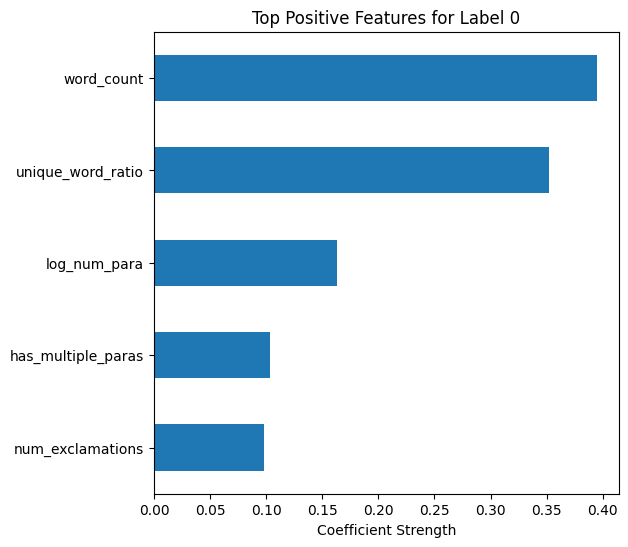

In [990]:
top_feats = top_features_for_label(0,5)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

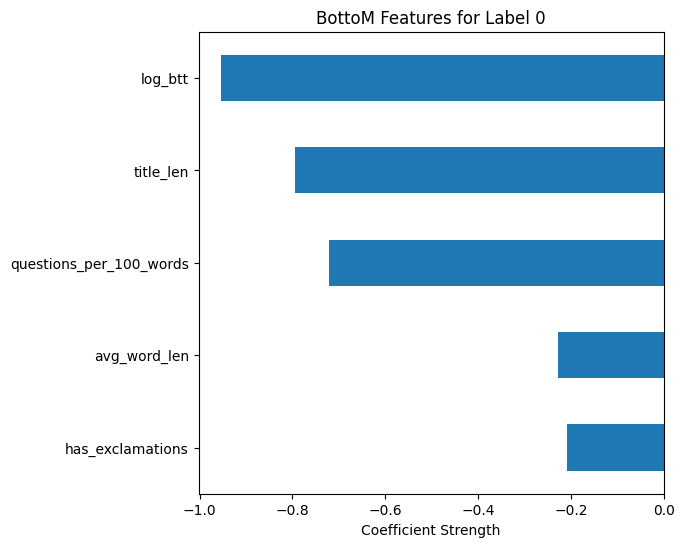

In [991]:
botton_feats = bottom_features_for_label(0,5)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

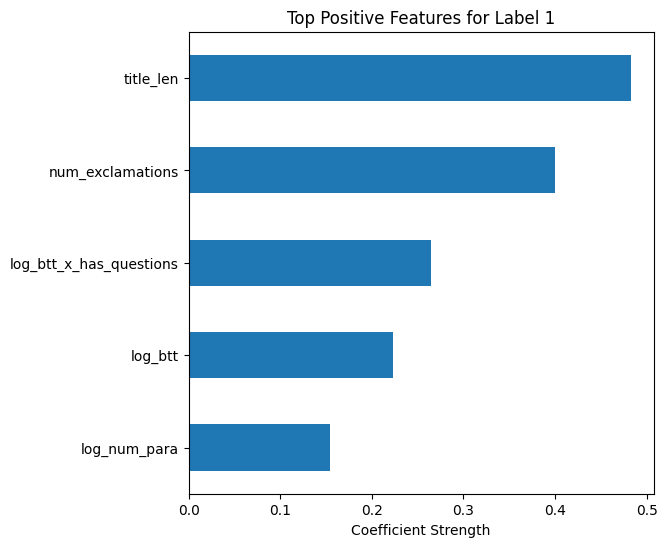

In [992]:
top_feats = top_features_for_label(1,5)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

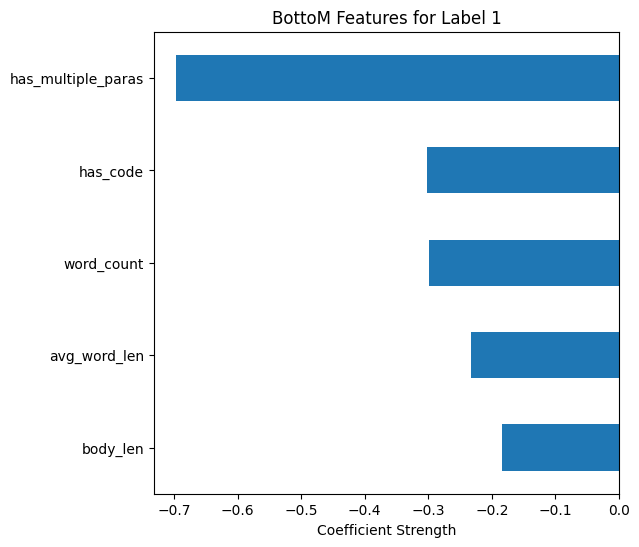

In [993]:
botton_feats = bottom_features_for_label(1,5)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

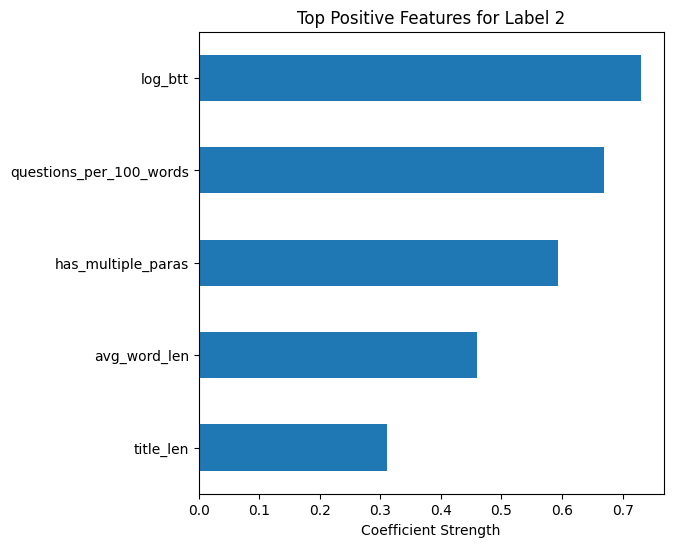

In [994]:
top_feats = top_features_for_label(2,5)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

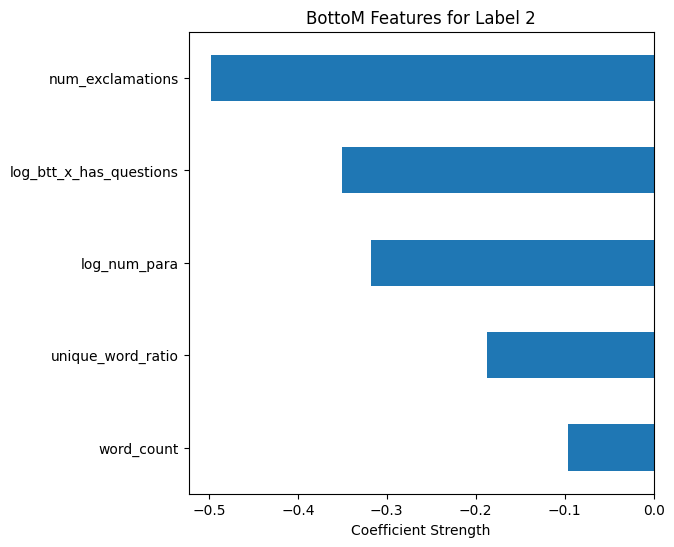

In [995]:
botton_feats = bottom_features_for_label(2,5)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

2. tf-idf only split

In [996]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts_train = (
    df_train["title"].fillna("") + "\n\n" + df_train["body"].fillna("")
)

texts_test = (
    df_test["title"].fillna("") + "\n\n" + df_test["body"].fillna("")
)

tfidf_only = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=3
)

X_train = tfidf_only.fit_transform(texts_train)
X_test = tfidf_only.transform(texts_test)

clf_tfidf_only = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

clf_tfidf_only.fit(X_train,y_train)
y_pred = clf_tfidf_only.predict(X_test)

print("TF-IDF only")
print(classification_report(y_test,y_pred))
errors_tfidf = build_error_df(df_test, y_test, y_pred,"tfidf_only")

TF-IDF only
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.43      0.60      0.50         5
           2       0.17      0.25      0.20         4

    accuracy                           0.31        13
   macro avg       0.20      0.28      0.23        13
weighted avg       0.22      0.31      0.25        13



c:\Users\prakh\projects\discusso-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prakh\projects\discusso-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prakh\projects\discusso-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [997]:


tfidf_features = tfidf_only.get_feature_names_out()

coef_df_for_tfidf_only = pd.DataFrame(
    clf_tfidf_only.coef_,
    columns=tfidf_features,
    index=clf_tfidf_only.classes_
)


def top_features_for_label(label, n=15):
    return (
        coef_df_for_tfidf_only.loc[label].sort_values(ascending = False).head(n)
    )
def bottom_features_for_label(label, n=15):
    return (
        coef_df_for_tfidf_only.loc[label].sort_values(ascending = True).head(n)
    )


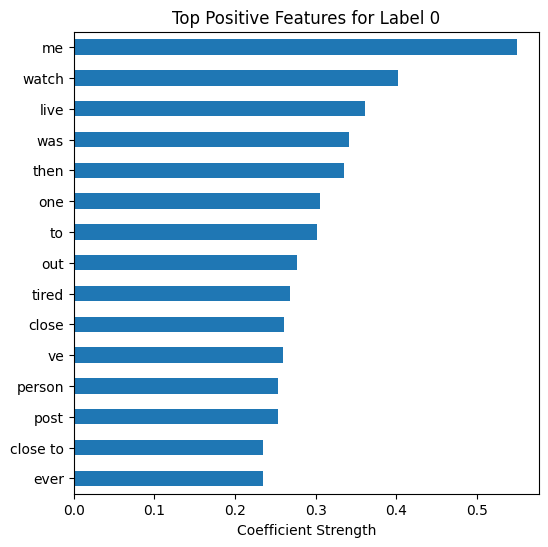

In [998]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

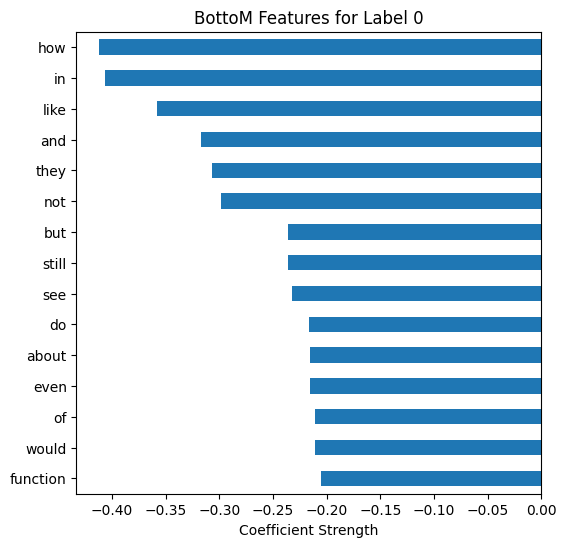

In [999]:
botton_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

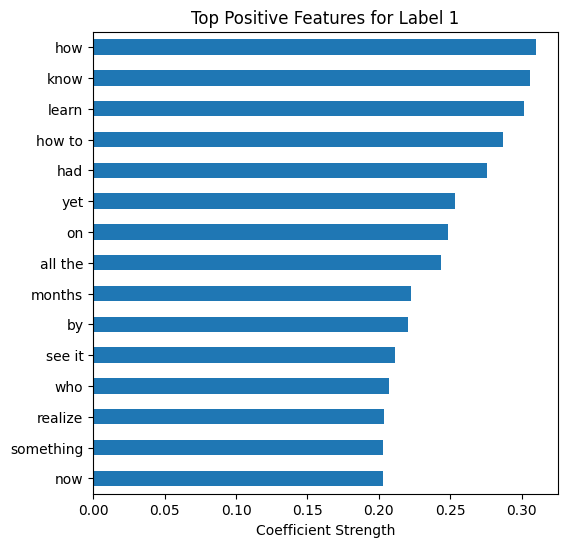

In [1000]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

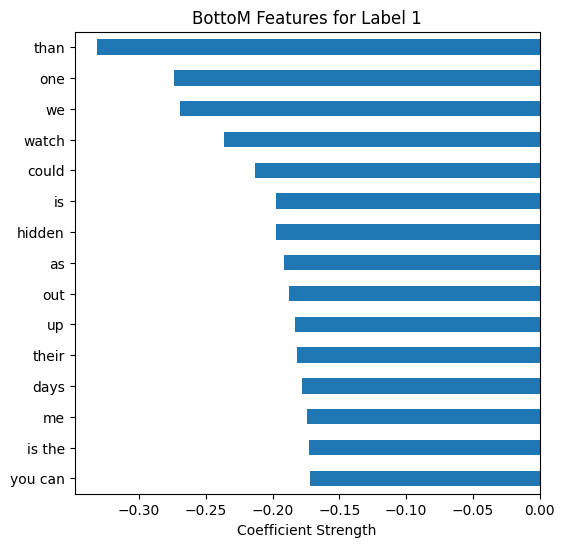

In [1001]:
botton_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

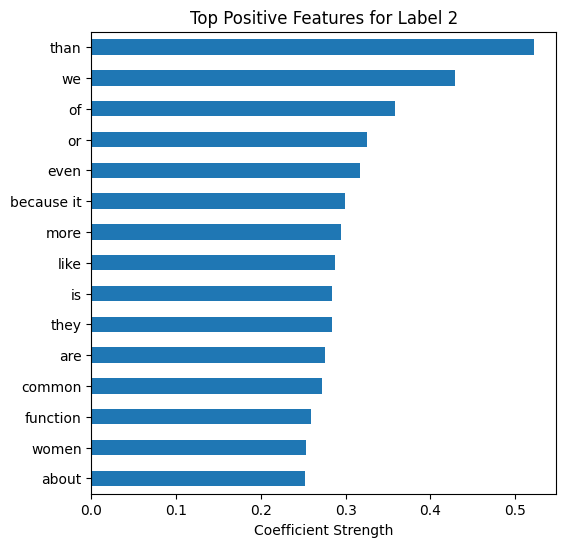

In [1002]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

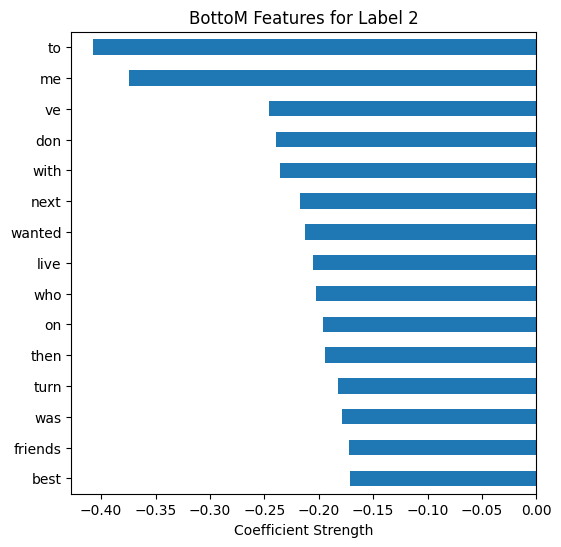

In [1003]:
botton_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

3. Embedding only

In [1004]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

emb_train = model.encode(texts_train.tolist(),batch_size=32)
emb_test = model.encode(texts_test.tolist(),batch_size=32)

clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

clf.fit(emb_train, y_train)
y_pred = clf.predict(emb_test)

print("Embedding only")
print(classification_report(y_test,y_pred))

errors_emb = build_error_df(df_test, y_test, y_pred, "embedding_only")

Embedding only
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.33      0.20      0.25         5
           2       0.14      0.25      0.18         4

    accuracy                           0.23        13
   macro avg       0.27      0.23      0.24        13
weighted avg       0.27      0.23      0.24        13



4. tfidf + numerical

In [1005]:
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression

# Vectorizer (fit ONCE)
tfidf = TfidfVectorizer(
    min_df=1,
    max_df=0.9,
    ngram_range=(1,2),
    max_features=3000
)

# scaler = StandardScaler()

# Text
train_text = df_train["title"].fillna("") + "\n\n" + df_train["body"].fillna("")
test_text  = df_test["title"].fillna("") + "\n\n" + df_test["body"].fillna("")

X_train_text = tfidf.fit_transform(train_text)
X_test_text  = tfidf.transform(test_text)

# Numeric
scaler = StandardScaler()
X_train_num = scaler.fit_transform(df_train[num_cols])
X_test_num  = scaler.transform(df_test[num_cols])

# Combine
X_train = hstack([X_train_text, X_train_num])
X_test  = hstack([X_test_text, X_test_num])

clf_tfidf_num = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_tfidf_num.fit(X_train, y_train)

y_pred_tfidf_num = clf_tfidf_num.predict(X_test)

print("TF-IDF + NUMERIC")
print(classification_report(y_test, y_pred_tfidf_num))




errors_tfidf_num = build_error_df(df_test, y_test,y_pred_tfidf_num,"tfidf_num")


TF-IDF + NUMERIC
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.75      0.60      0.67         5
           2       0.75      0.75      0.75         4

    accuracy                           0.69        13
   macro avg       0.70      0.70      0.69        13
weighted avg       0.70      0.69      0.69        13



In [1006]:
## Getting vocabulary frequency per label
'''
clf = pipe.named_steps['clf']
preprocessor = pipe.named_steps['prep']

tfidf = preprocessor.named_transformers_['text']
tfidf_features = tfidf.get_feature_names_out()

all_features = list(tfidf_features) + numerical_feature

coef_df = pd.DataFrame(
    clf.coef_,
    columns=all_features,
    index=clf.classes_
)
## Getting top words per label 
def top_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = False).head(n)
    )

def bottom_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = True).head(n)
    )
'''



"\nclf = pipe.named_steps['clf']\npreprocessor = pipe.named_steps['prep']\n\ntfidf = preprocessor.named_transformers_['text']\ntfidf_features = tfidf.get_feature_names_out()\n\nall_features = list(tfidf_features) + numerical_feature\n\ncoef_df = pd.DataFrame(\n    clf.coef_,\n    columns=all_features,\n    index=clf.classes_\n)\n## Getting top words per label \ndef top_features_for_label(label, n=15):\n    return (\n        coef_df.loc[label].sort_values(ascending = False).head(n)\n    )\n\ndef bottom_features_for_label(label, n=15):\n    return (\n        coef_df.loc[label].sort_values(ascending = True).head(n)\n    )\n"

In [1007]:
numeric_feature = df.select_dtypes(include='number').columns.tolist()
numeric_feature.remove("label")

tfidf_features = tfidf.get_feature_names_out()
# tfidf_features
all_features = list(tfidf_features) + numeric_feature

coef_df = pd.DataFrame(
    clf_tfidf_num.coef_,
    columns=all_features,
    index=clf.classes_
)

def top_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = False).head(n)
    )
def bottom_features_for_label(label, n=15):
    return (
        coef_df.loc[label].sort_values(ascending = True).head(n)
    )


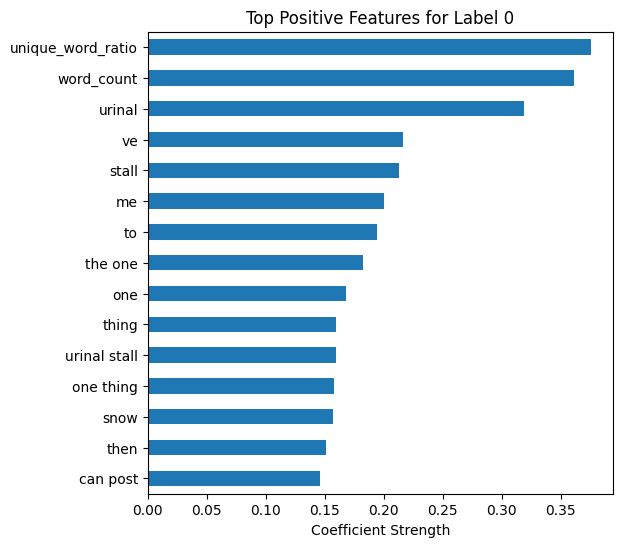

In [1008]:
top_feats = top_features_for_label(0,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

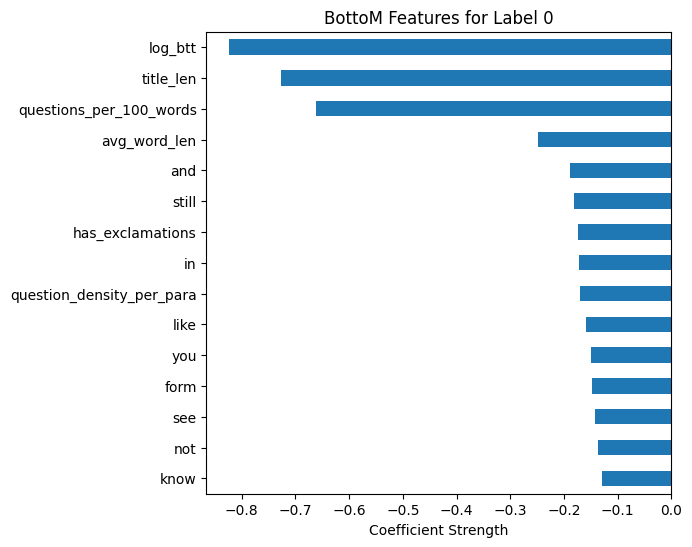

In [1009]:
botton_feats = bottom_features_for_label(0,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 0")
plt.xlabel("Coefficient Strength")
plt.show()

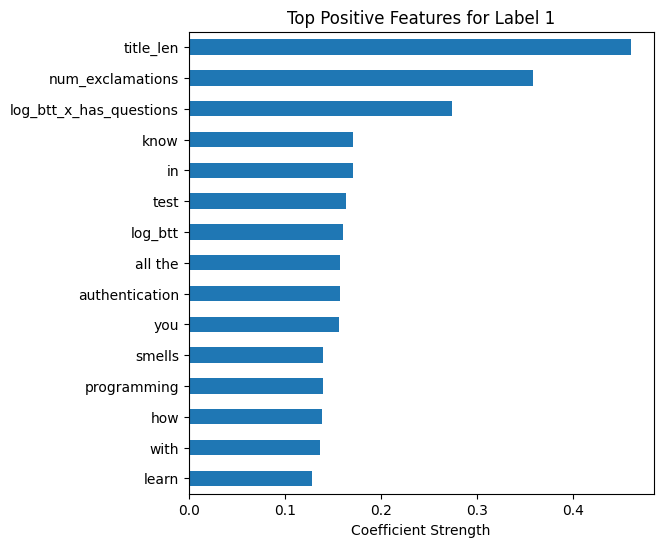

In [1010]:
top_feats = top_features_for_label(1,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

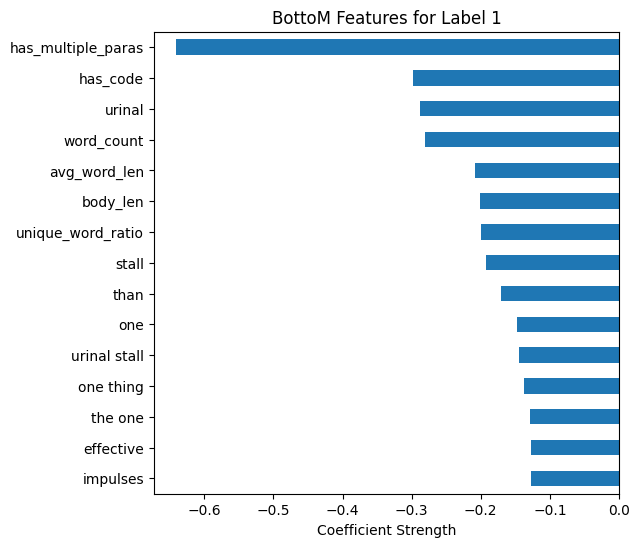

In [1011]:
botton_feats = bottom_features_for_label(1,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 1")
plt.xlabel("Coefficient Strength")
plt.show()

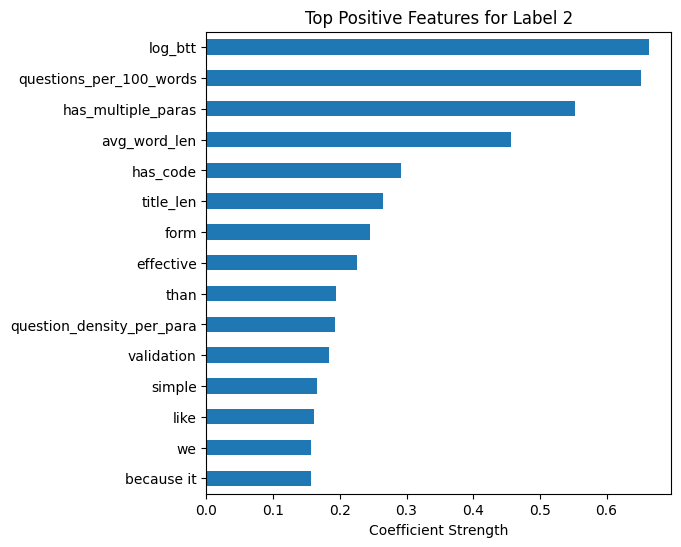

In [1012]:
top_feats = top_features_for_label(2,15)

plt.figure(figsize=(6,6))
top_feats[::-1].plot(kind='barh')
plt.title("Top Positive Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

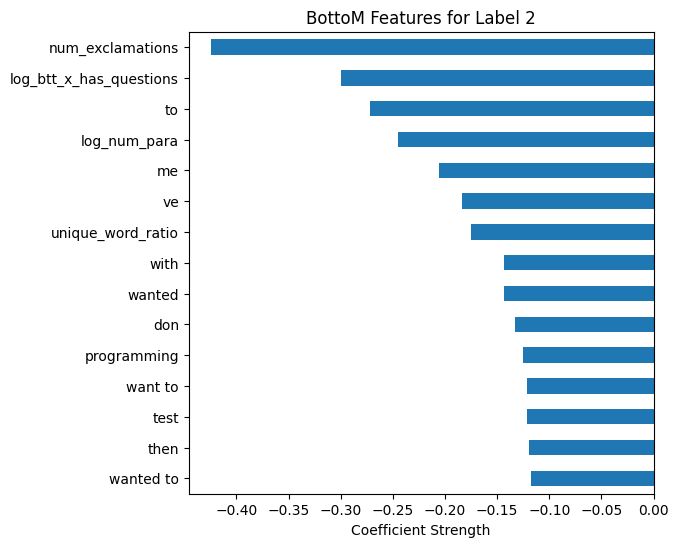

In [1013]:
botton_feats = bottom_features_for_label(2,15)

plt.figure(figsize=(6,6))
botton_feats[::-1].plot(kind='barh')
plt.title("BottoM Features for Label 2")
plt.xlabel("Coefficient Strength")
plt.show()

5. Embedding + numerical

In [1014]:
from sentence_transformers import SentenceTransformer
import numpy as np

scaler = StandardScaler()

embedder = SentenceTransformer("all-MiniLM-L6-v2")

X_train_text = embedder.encode(df_train["text"].tolist(), show_progress_bar=True)
X_test_text  = embedder.encode(df_test["text"].tolist(), show_progress_bar=True)


X_train_num = scaler.fit_transform(df_train[num_cols])
X_test_num = scaler.transform(df_test[num_cols])


X_train = np.hstack([X_train_text, X_train_num])
X_test  = np.hstack([X_test_text, X_test_num])

y_train = df_train["label"]
y_test = df_test["label"]


clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

clf.fit(X_train,y_train)

y_pred_emb_num = clf.predict(X_test)


print("EMBEDDING + NUMERIC")
print(classification_report(y_test, y_pred_emb_num))

errors_emb_num = build_error_df(df_test,y_test,y_pred_emb_num,"embedding_num")

Batches: 100%|██████████| 1/1 [00:00<00:00,  3.64it/s]

EMBEDDING + NUMERIC
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.75      0.60      0.67         5
           2       0.75      0.75      0.75         4

    accuracy                           0.69        13
   macro avg       0.70      0.70      0.69        13
weighted avg       0.70      0.69      0.69        13



In [1015]:
error_all = pd.concat(
    [
        errors_num,
        errors_tfidf,
        errors_emb,
        errors_tfidf_num,
        errors_emb_num
    ],
    ignore_index=True
)

In [1016]:
error_all["error_type"] = ""
error_all["error_subtype"] = ""
error_all["notes"] = ""


In [1017]:
wrong = error_all[error_all["correct"] == False].copy()
wrong = wrong.reset_index(drop=True)

wrong.shape

(31, 27)

In [1018]:
wrong

,title,body,code,label,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,...,log_btt_x_has_questions,question_density_per_para,first_person_ratio,true_label,pred_label,correct,model,error_type,error_subtype,notes
0,"Be honest, what do you think comes after death?",,,1,"Be honest, what do you think comes after death...",47,0,0,0,0,...,-3.871201,1.00,0.0,1,0,False,numerical_only,,,
1,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,0,"""American Problems"" which doesn't exist anywhe...",54,175,0,0,0,...,1.163151,2.00,0.0,0,2,False,numerical_only,,,
2,Living in a foreign country is taking its tow,"I love the country I choose to live, since it ...",,1,Living in a foreign country is taking its tow\...,45,285,0,1,0,...,0.000000,0.00,0.0,1,0,False,numerical_only,,,
3,CMV: I believe a big majority of social media ...,I think a lot of bad or overtly loud internet ...,,2,CMV: I believe a big majority of social media ...,69,625,0,0,0,...,0.000000,0.00,0.0,2,1,False,numerical_only,,,
4,Should masturbation be something couples openl...,My partner (27M) and I (24F) live together and...,,2,Should masturbation be something couples openl...,56,1424,0,1,0,...,3.218876,0.75,0.0,2,1,False,tfidf_only,,,
5,"Why do strangers in Western countries ask ""How...","In my home country, asking someone ""How are yo...",,2,"Why do strangers in Western countries ask ""How...",111,521,0,0,0,...,1.539169,4.00,0.0,2,1,False,tfidf_only,,,
6,Why are genetic differences in appearance and ...,"I mean, different human races have lived in di...",,1,Why are genetic differences in appearance and ...,188,210,0,0,0,...,0.110111,2.00,0.0,1,2,False,tfidf_only,,,
7,Stripe Native crashes on google pixel device,I’m integrating Stripe PaymentSheet (React Nat...,const openPaymentSheet = async () => {\n try ...,2,Stripe Native crashes on google pixel device\n...,44,331,0,1,0,...,0.000000,0.00,0.0,2,1,False,tfidf_only,,,
8,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,0,"""American Problems"" which doesn't exist anywhe...",54,175,0,0,0,...,1.163151,2.00,0.0,0,2,False,tfidf_only,,,
9,Say something in a language other than English...,,,0,Say something in a language other than English...,92,0,0,0,0,...,-0.000000,0.00,0.0,0,2,False,tfidf_only,,,


# Doing Error taxonomy for numerical only model and trying to make some numerical feature to reduce Category B errors.

In [1037]:
wrong_num = wrong[wrong['model']=='numerical_only'].copy()
wrong_num.reset_index(drop=True)
wrong_num

,title,body,code,label,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,...,log_btt_x_has_questions,question_density_per_para,first_person_ratio,true_label,pred_label,correct,model,error_type,error_subtype,notes
0,"Be honest, what do you think comes after death?",,,1,"Be honest, what do you think comes after death...",47,0,0,0,0,...,-3.871201,1.0,0.0,1,0,False,numerical_only,B,"""Open question undervalued""","""The numerical-only model over-penalizes short..."
1,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,0,"""American Problems"" which doesn't exist anywhe...",54,175,0,0,0,...,1.163151,2.0,0.0,0,2,False,numerical_only,B,"""Context mistaken as depth""","""The numerical-only model incorrectly treats c..."
2,Living in a foreign country is taking its tow,"I love the country I choose to live, since it ...",,1,Living in a foreign country is taking its tow\...,45,285,0,1,0,...,0.000000,0.0,0.0,1,0,False,numerical_only,B,"""Implicit advice ignored""","""The numerical-only model treats the absence o..."
3,CMV: I believe a big majority of social media ...,I think a lot of bad or overtly loud internet ...,,2,CMV: I believe a big majority of social media ...,69,625,0,0,0,...,0.000000,0.0,0.0,2,1,False,numerical_only,,,


In [1038]:
wrong_num.iloc[0]

title                          Be honest, what do you think comes after death?
body                                                                          
code                                                                          
label                                                                        1
text                         Be honest, what do you think comes after death...
title_len                                                                   47
body_len                                                                     0
num_exclamations                                                             0
has_multiple_paras                                                           0
has_exclamations                                                             0
questions_per_100_words                                               1.587302
log_num_para                                                          0.693147
word_count                                          

In [1039]:
wrong_num.loc[0, 'error_type'] = "B"
wrong_num.loc[0, 'error_subtype'] = "\"Open question undervalued\""
wrong_num.loc[0, 'notes'] = "\"The numerical-only model over-penalizes short length and lack of contextual framing, implicitly equating brevity with low discussion quality. While the post lacks author investment, it is an open-ended philosophical question with no single correct answer, making it likely to generate diverse opinion-based responses. This reflects a feature–label mismatch where response entropy and openness are undervalued relative to structural effort signals. The error could be mitigated by introducing numerical features such as is_open_ended_question (binary indicator for abstract, non-factual questions), answer_convergence_likelihood (estimated probability that responses will vary rather than converge), and single_correct_answer_flag (binary feature indicating whether the question admits a definitive answer). These features would allow the model to separate low-effort prompts from genuinely discussion-capable open questions despite short length.\""

In [1040]:
wrong_num.iloc[1]

title                        "American Problems" which doesn't exist anywhe...
body                         Have noticed most of the americans are having ...
code                                                                          
label                                                                        0
text                         "American Problems" which doesn't exist anywhe...
title_len                                                                   54
body_len                                                                   175
num_exclamations                                                             0
has_multiple_paras                                                           0
has_exclamations                                                             0
questions_per_100_words                                               3.174603
log_num_para                                                          0.693147
word_count                                          

In [1041]:
wrong_num.loc[1, 'error_type'] = "B"
wrong_num.loc[1, 'error_subtype'] = "\"Context mistaken as depth\""
wrong_num.loc[1, 'notes'] = "\"The numerical-only model incorrectly treats contextual framing and topic specificity as strong indicators of high discussion quality, failing to account for response convergence. Although the post provides some background, it asks a largely explanatory question with predictable, repetitive answers, aligning with Label 1 rather than Label 2. This reflects a feature–label mismatch where author context is overvalued and expected response diversity is not modeled. The error could be mitigated by incorporating numerical features such as answer_convergence_likelihood (estimated probability that replies will be similar), explanatory_vs_debatable_score (degree to which a question seeks explanation rather than opinion), and constraint_count (number of explicit conditions or trade-offs shaping responses). These features would help distinguish structured discussion prompts from broadly informational questions.\""

In [1042]:
wrong_num.iloc[2]

title                            Living in a foreign country is taking its tow
body                         I love the country I choose to live, since it ...
code                                                                          
label                                                                        1
text                         Living in a foreign country is taking its tow\...
title_len                                                                   45
body_len                                                                   285
num_exclamations                                                             0
has_multiple_paras                                                           1
has_exclamations                                                             0
questions_per_100_words                                                    0.0
log_num_para                                                          1.098612
word_count                                          

In [1043]:
wrong_num.loc[2, 'error_type'] = "B"
wrong_num.loc[2, 'error_subtype'] = "\"Implicit advice ignored\""
wrong_num.loc[2, 'notes'] = "\"The numerical-only model treats the absence of explicit questions as a strong indicator of low-quality content, failing to capture implicit advice-seeking and experiential sharing common in personal struggle posts. Although the author does not directly ask for help, the emotional framing and situational context naturally invite empathetic and advisory responses. This reflects a feature–label mismatch where interrogative structure is overvalued relative to implicit intent. Introducing features such as implicit_advice_signal (presence of emotional difficulty without resolution), experience_sharing_score (first-person narrative describing an unresolved situation), and support_response_likelihood (estimated probability of empathetic or advisory replies) would help distinguish low-effort vents from discussion-capable personal reflections.\""

In [1034]:
wrong_num.iloc[3]

title                        CMV: I believe a big majority of social media ...
body                         I think a lot of bad or overtly loud internet ...
code                                                                          
label                                                                        2
text                         CMV: I believe a big majority of social media ...
title_len                                                                   69
body_len                                                                   625
num_exclamations                                                             0
has_multiple_paras                                                           0
has_exclamations                                                             0
questions_per_100_words                                                    0.0
log_num_para                                                          0.693147
word_count                                          

In [1044]:
wrong_num.loc[3, 'error_type'] = "B"
wrong_num.loc[3, 'error_subtype'] = "\"Opinion framed as vagueness\""
wrong_num.loc[3, 'notes'] = "\"The numerical-only model fails to properly weight explicit debate indicators such as CMV framing and strong opinion statements, instead relying heavily on interrogative structure and question presence to infer discussion quality. Although the post clearly invites disagreement and multiperspective debate, it is misclassified due to an over-penalization of declarative phrasing. This reflects a feature–label mismatch rather than a representational gap. Introducing features such as debate_frame_present (binary indicator for CMV or equivalent markers), opinion_strength_score (degree of assertive, evaluative language), and disagreement_invitation_signal (presence of phrases implying openness to rebuttal) would help align the model with the intended label definitions.\""

In [1045]:
wrong_num

,title,body,code,label,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,...,log_btt_x_has_questions,question_density_per_para,first_person_ratio,true_label,pred_label,correct,model,error_type,error_subtype,notes
0,"Be honest, what do you think comes after death?",,,1,"Be honest, what do you think comes after death...",47,0,0,0,0,...,-3.871201,1.0,0.0,1,0,False,numerical_only,B,"""Open question undervalued""","""The numerical-only model over-penalizes short..."
1,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,0,"""American Problems"" which doesn't exist anywhe...",54,175,0,0,0,...,1.163151,2.0,0.0,0,2,False,numerical_only,B,"""Context mistaken as depth""","""The numerical-only model incorrectly treats c..."
2,Living in a foreign country is taking its tow,"I love the country I choose to live, since it ...",,1,Living in a foreign country is taking its tow\...,45,285,0,1,0,...,0.000000,0.0,0.0,1,0,False,numerical_only,B,"""Implicit advice ignored""","""The numerical-only model treats the absence o..."
3,CMV: I believe a big majority of social media ...,I think a lot of bad or overtly loud internet ...,,2,CMV: I believe a big majority of social media ...,69,625,0,0,0,...,0.000000,0.0,0.0,2,1,False,numerical_only,B,"""Opinion framed as vagueness""","""The numerical-only model fails to properly we..."


In [1046]:
## Saving the error_taxonomy_v1 for numerical model
wrong_num.to_csv("../data/post_quality/processed/numerical_error_taxonomy_v1.csv",index=False)

In [1047]:
wrong_num['error_type'].value_counts()

error_type
B    4
Name: count, dtype: int64

In [1063]:
wrong_num['error_subtype'].unique()

array(['"Open question undervalued"', '"Context mistaken as depth"',
       '"Implicit advice ignored"', '"Opinion framed as vagueness"'],
      dtype=object)

# **Observation**: 
The error taxonomy analysis of the numerical-only model reveals that all observed misclassifications fall under Category B, indicating feature–label mismatches rather than fundamental model limitations. The model consistently overweights structural effort signals such as length and explicit questions while undervaluing response diversity, implicit intent, and debate framing. Errors frequently arise when short but open-ended questions, experiential narratives without explicit interrogatives, or declarative opinion posts intended for debate are misclassified as low-quality. These findings suggest that the primary limitation lies in missing numerical proxies for answer convergence, openness, implicit advice-seeking, and disagreement invitation. Targeted feature engineering addressing these dimensions is expected to substantially reduce error rates before transitioning to semantic or embedding-based models.

### Freezing the baseline: Let's take the same train-test split. I will get the classification report and all other things at once

In [ ]:
## Let's build a helper function to make error_df
import pandas as pd

def build_error_df(df_test, y_true, y_pred, model_name):
    out = df_test.copy()
    out['true_label'] = y_true
    out['pred_label'] = y_pred
    out['correct'] = y_true == y_pred
    out['model'] = model_name
    return out

In [1053]:
## Generic function to split df in same test and train
from sklearn.model_selection import train_test_split


def split_df(
    df,
    label_col,
    test_size=0.2,
    random_state=52,
    stratify=True
):
    """
    Splits dataframe into train and test sets.

    Returns
    -------
    df_train : pd.DataFrame
    df_test : pd.DataFrame
    """

    df = df.reset_index(drop=True)

    stratify_col = df[label_col] if stratify else None

    train_idx, test_idx = train_test_split(
        df.index,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_col
    )

    df_train = df.loc[train_idx]
    df_test = df.loc[test_idx]

    return df_train, df_test


In [1059]:
## Running numerical only model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


def run_numerical_model(
    df_train,
    df_test,
    label_col,
    num_cols=None,
    model=None,
    scaler=None,
    model_name="numerical_only"
):
    """
    Trains and evaluates a numerical-only classification model.

    Returns
    -------
    dict with:
        - model
        - scaler
        - classification_report
        - errors_df
        - y_pred
    """

    if num_cols is None:
        num_cols = df_train.select_dtypes(include="number").columns.tolist()
        num_cols.remove(label_col)

    if scaler is None:
        scaler = StandardScaler()

    if model is None:
        model = LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )

    X_train = scaler.fit_transform(df_train[num_cols])
    X_test = scaler.transform(df_test[num_cols])

    y_train = df_train[label_col]
    y_test = df_test[label_col]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred)

    errors_df = build_error_df(
        df_test=df_test,
        y_true=y_test,
        y_pred=y_pred,
        model_name=model_name
    )

    errors_df['error_type'] = ''
    errors_df['error_subtype'] = ''
    errors_df['notes'] = ''

    return {
        "model": model,
        "scaler": scaler,
        "classification_report": report,
        "errors_df": errors_df,
        "y_pred": y_pred
    }


### Let's try solving the error subtype `Open question undervalued`
#### Error explanation:
* Right now my model is thinking like this `too short-> low effort -> label 0`
* But, in reality, if in human terms we can show the model like `open ended question-> many diverse answers-> label 1(high response quality)`
Conclusion : Model is not missing features for getting length , it is missing **features for openness**. View **post_quality_v1_1.ipynb**

### Goal of this experiment:
**Teach the model**: Some short questions are still discussion-worthy if they are open-ended

#### Operational definition:
A question is open-ended if:
* It does not have a single factual answer
* It invites opinions, belief, or speculation.

**Examples:**
* What do you think comes after death?(Open ended)
* What is the boiling point of water?(factual)

In [1067]:
wrong_num[wrong_num['error_subtype']=="\"Open question undervalued\""]

,title,body,code,label,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,...,log_btt_x_has_questions,question_density_per_para,first_person_ratio,true_label,pred_label,correct,model,error_type,error_subtype,notes
0,"Be honest, what do you think comes after death?",,,1,"Be honest, what do you think comes after death...",47,0,0,0,0,...,-3.871201,1.0,0.0,1,0,False,numerical_only,B,"""Open question undervalued""","""The numerical-only model over-penalizes short..."


,title,body,code,label,text,title_len,body_len,num_exclamations,has_multiple_paras,has_exclamations,...,question_density_per_para,first_person_ratio,is_open_ended_question,true_label,pred_label,correct,model,error_type,error_subtype,notes
35,"Be honest, what do you think comes after death?",,,1,"Be honest, what do you think comes after death...",47,0,0,0,0,...,1.0,0.0,1,1,0,False,numerical_only,,,
4,"""American Problems"" which doesn't exist anywhe...",Have noticed most of the americans are having ...,,0,"""American Problems"" which doesn't exist anywhe...",54,175,0,0,0,...,2.0,0.0,0,0,2,False,numerical_only,,,
27,Living in a foreign country is taking its tow,"I love the country I choose to live, since it ...",,1,Living in a foreign country is taking its tow\...,45,285,0,1,0,...,0.0,0.0,0,1,0,False,numerical_only,,,
22,CMV: I believe a big majority of social media ...,I think a lot of bad or overtly loud internet ...,,2,CMV: I believe a big majority of social media ...,69,625,0,0,0,...,0.0,0.0,0,2,1,False,numerical_only,,,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      63 non-null     object 
 1   body                       63 non-null     object 
 2   code                       63 non-null     object 
 3   label                      63 non-null     int64  
 4   text                       63 non-null     object 
 5   title_len                  63 non-null     int64  
 6   body_len                   63 non-null     int64  
 7   num_exclamations           63 non-null     int64  
 8   has_multiple_paras         63 non-null     int64  
 9   has_exclamations           63 non-null     int64  
 10  questions_per_100_words    63 non-null     float64
 11  log_num_para               63 non-null     float64
 12  word_count                 63 non-null     int64  
 13  avg_word_len               63 non-null     float64
 